# Blogs

In [1]:
import sys
import os
sys.path.append(os.path.abspath("..\\.."))
from Modules.latentspacemodel import *
from Modules.inference import *
from Modules.afteranalyses import *

## Network

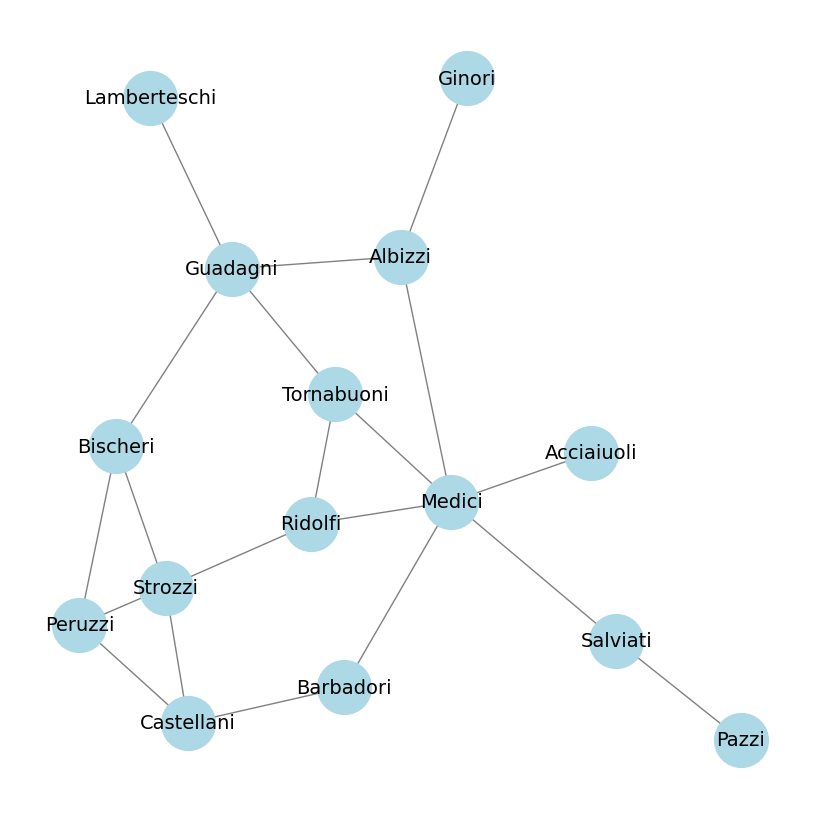

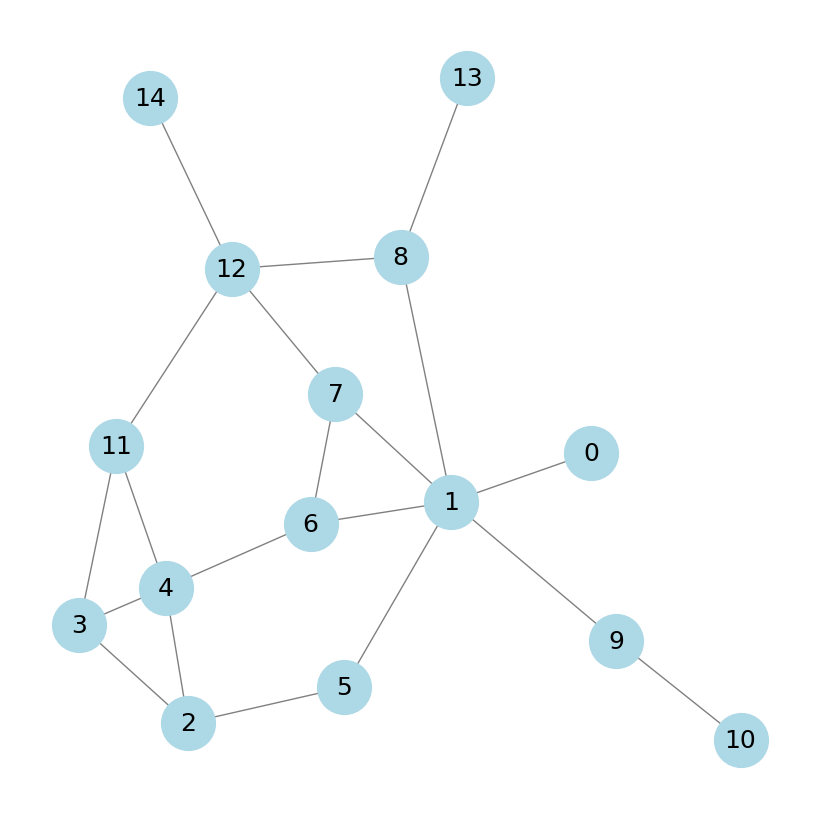

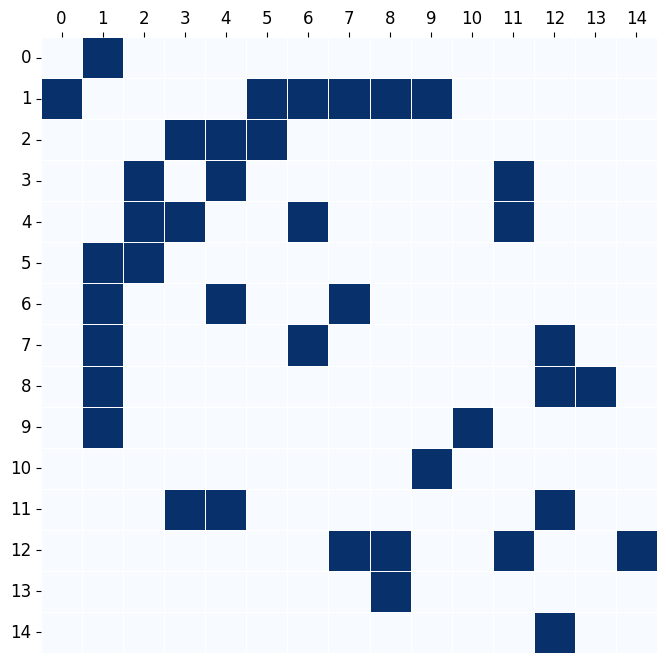

In [2]:
G = nx.florentine_families_graph()
pos = nx.spring_layout(G,seed=80)
plt.figure(figsize=(8,8))
nx.draw(G, pos=pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, font_size=14)
#plt.title("Florentine Families network")
plt.show()

G = nx.florentine_families_graph()
node_mapping = {node: i for i, node in enumerate(G.nodes())}
G = nx.relabel_nodes(G, node_mapping)
plt.figure(figsize=(8,8))
pos_relabel = {node_mapping[k]: v for k, v in pos.items()}
nx.draw(G,  pos=pos_relabel, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, font_size=18)
#plt.title("Florentine Families network with relabeled nodes")
plt.show()
#print("Map from original nodes to new nodes:")
#print(node_mapping)

Y = nx.to_numpy_array(G, dtype=float)
n = Y.shape[0]
plt.figure(figsize=(8,8))
sns.heatmap(Y, annot=False, cmap="Blues", cbar=False, square=True, linewidths=0.5, linecolor='white')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.gca().xaxis.tick_top() 
plt.gca().tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=12)
#plt.title("Sociomatrix for Florentine families")
plt.show() 

In [3]:
seed_MAP = 42
diam = 10.0
n = Y.shape[0]
lr_MAP = 1e-2
n_starts_MAP = 1
n_iter_MAP = 25000
n_sim_iv = 2500
n_iter_cv = 1000
n_folds_cv = 5

## Models over $\mathbb{R}^d$

### Model $\mathbb{R^1}$

#### Without weights

Multi_start (5)


MAP:  58%|█████▊    | 14413/25000 [03:51<02:49, 62.38it/s, logpost=-43.2631, loglik=-42.7137, logprior=-0.5494, ||grad||=0.0010, patience=100]


[STOP] Early stopping at iter 14412 (no improvement in 101 steps)


MAP:  58%|█████▊    | 14413/25000 [04:11<03:04, 57.26it/s, logpost=-43.2631, loglik=-42.7137, logprior=-0.5494, ||grad||=0.0010, patience=100]


[STOP] Early stopping at iter 14412 (no improvement in 101 steps)


...

[STOP] Early stopping at iter 14412 (no improvement in 101 steps)


MAP:  58%|█████▊    | 14413/25000 [04:20<03:11, 55.26it/s, logpost=-43.2631, loglik=-42.7137, logprior=-0.5494, ||grad||=0.0010, patience=100]


[STOP] Early stopping at iter 14412 (no improvement in 101 steps)


MAP:  58%|█████▊    | 14413/25000 [04:43<03:28, 50.79it/s, logpost=-43.2631, loglik=-42.7137, logprior=-0.5494, ||grad||=0.0010, patience=100]


[STOP] Early stopping at iter 14412 (no improvement in 101 steps)

Best log-posterior: -43.2631


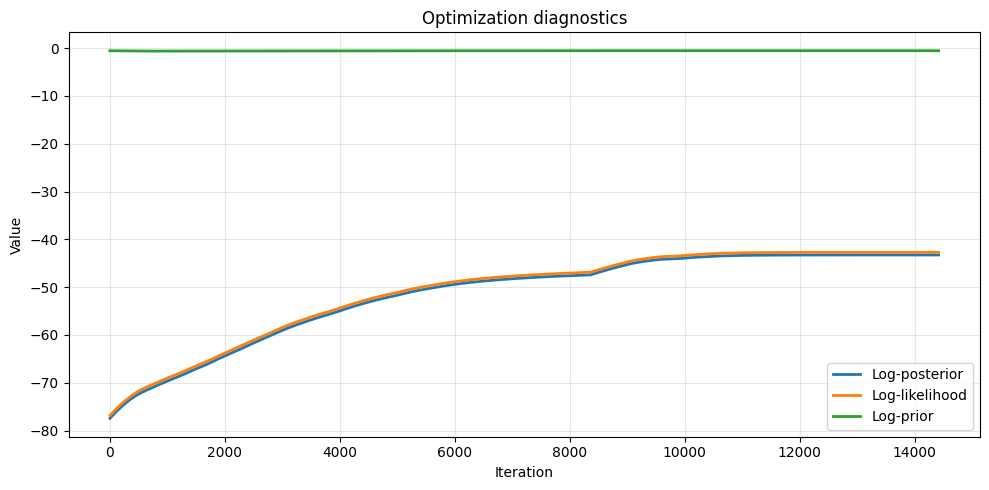

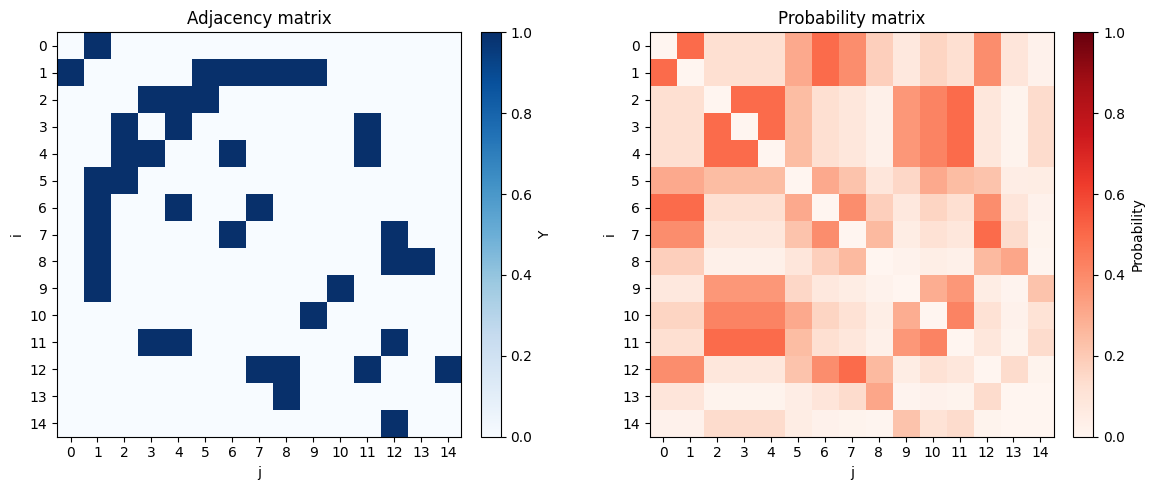

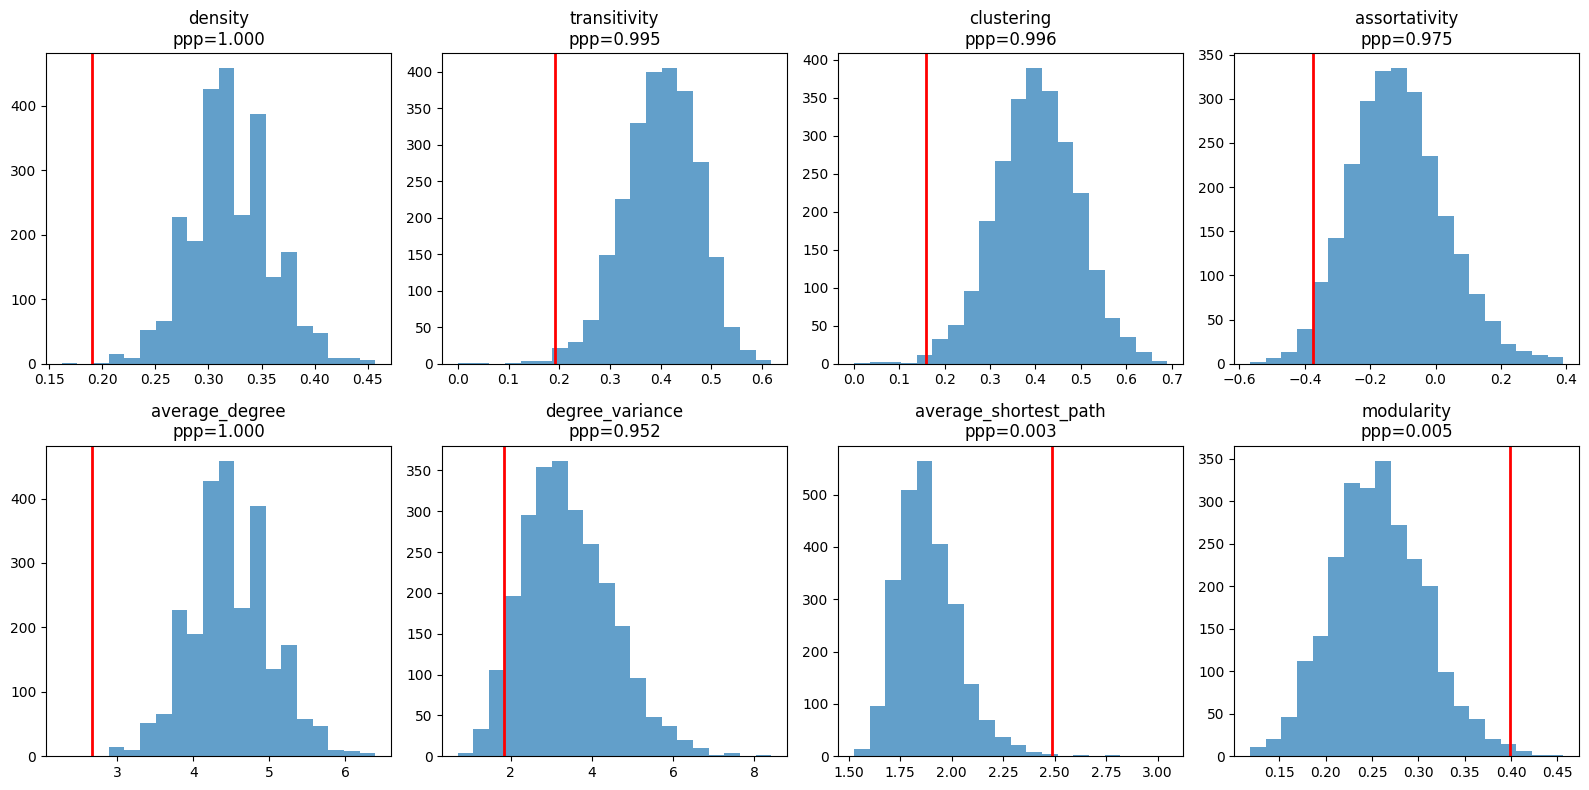

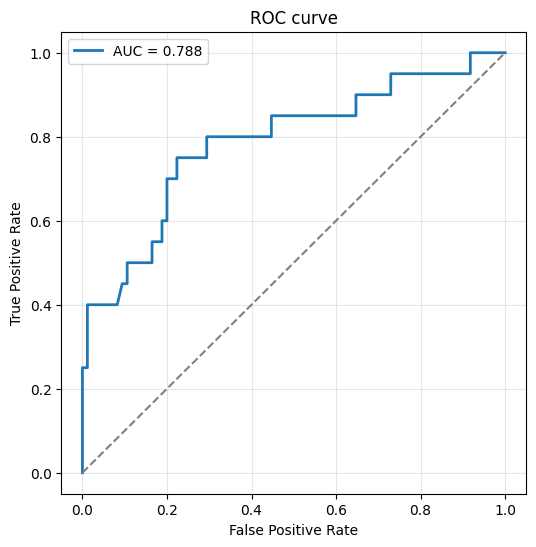

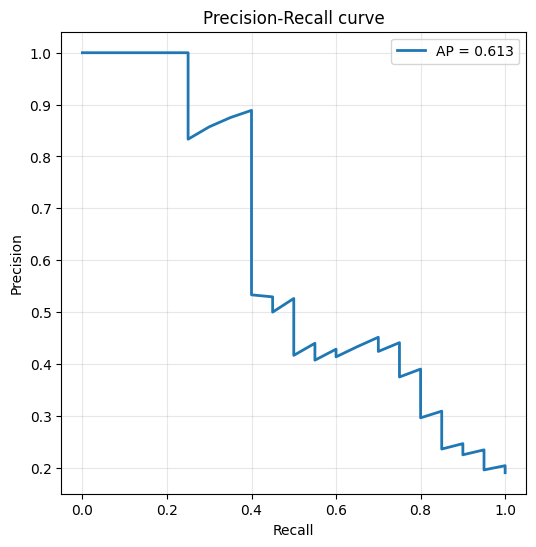

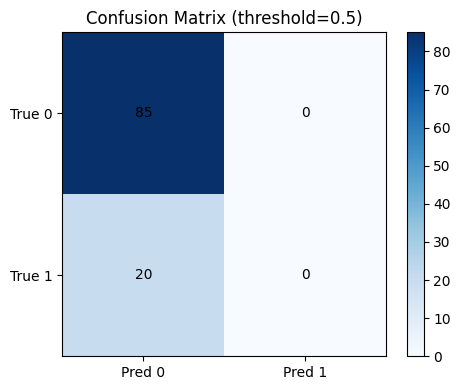

MAP: 100%|██████████| 1000/1000 [00:19<00:00, 50.92it/s, logpost=-29.1104, loglik=-28.5502, logprior=-0.5602, ||grad||=0.0010, patience=0]


{'mean_auc': 0.7572623552344914, 'std_auc': 0.11902804091268696, 'min_auc': np.float64(0.6176470588235294), 'max_auc': np.float64(0.9473684210526316), 'n_folds': 5}


In [4]:
geometry = EuclideanGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R1_c.pkl")

#### With weights

Multi_start (5)


MAP:  72%|███████▏  | 18058/25000 [2:23:47<55:16,  2.09it/s, logpost=-36.8924, loglik=-36.8924, logprior=0.0000, ||grad||=0.0010, patience=100]   


[STOP] Early stopping at iter 18057 (no improvement in 101 steps)


MAP:  72%|███████▏  | 18058/25000 [12:08:58<4:40:14,  2.42s/it, logpost=-36.8924, loglik=-36.8924, logprior=0.0000, ||grad||=0.0010, patience=100]   


[STOP] Early stopping at iter 18057 (no improvement in 101 steps)


...

[STOP] Early stopping at iter 18057 (no improvement in 101 steps)


MAP:  72%|███████▏  | 18058/25000 [03:31<01:21, 85.36it/s, logpost=-36.8924, loglik=-36.8924, logprior=0.0000, ||grad||=0.0010, patience=100]


[STOP] Early stopping at iter 18057 (no improvement in 101 steps)


MAP:  72%|███████▏  | 18058/25000 [03:28<01:20, 86.70it/s, logpost=-36.8924, loglik=-36.8924, logprior=0.0000, ||grad||=0.0010, patience=100]


[STOP] Early stopping at iter 18057 (no improvement in 101 steps)

Best log-posterior: -36.8924


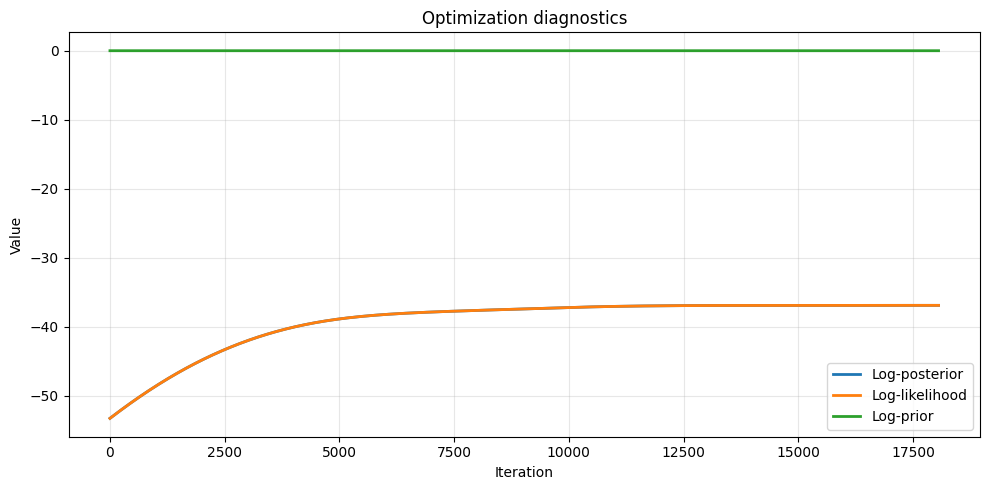

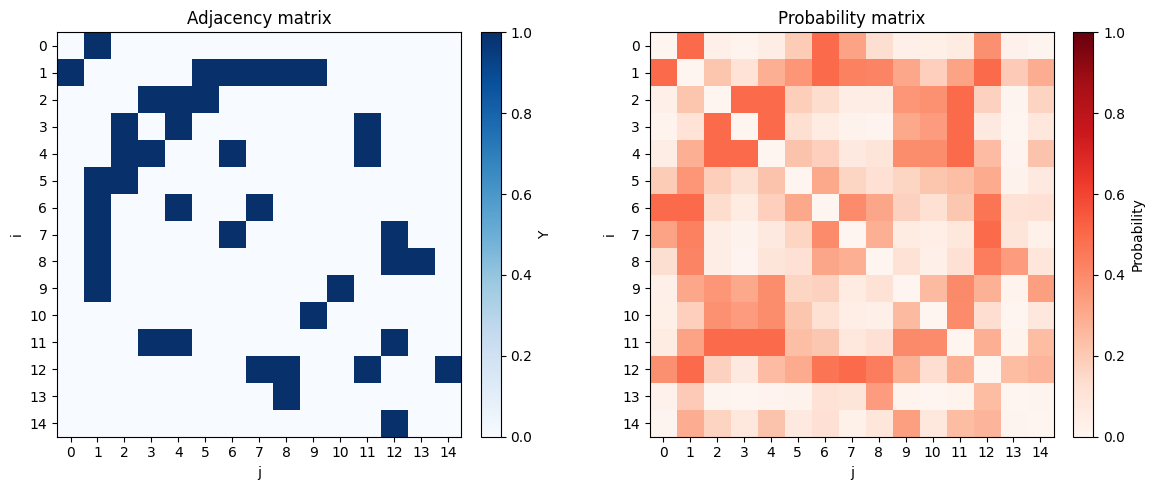

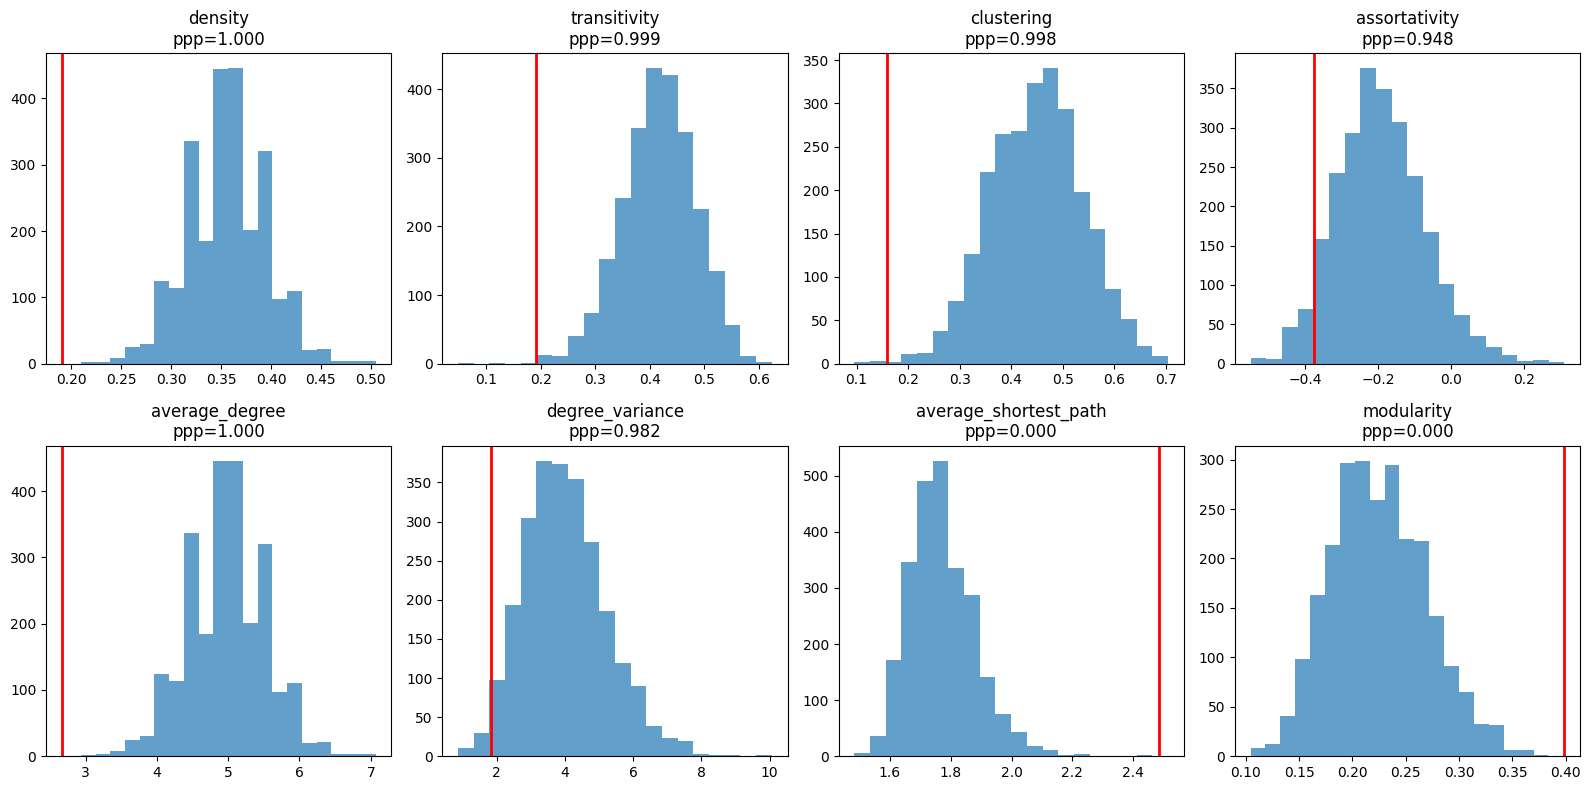

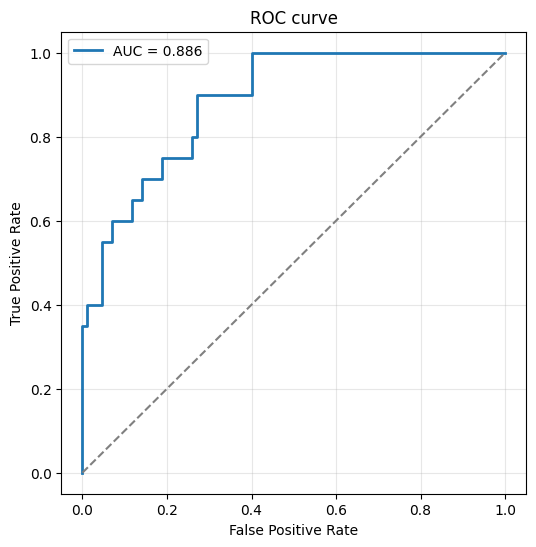

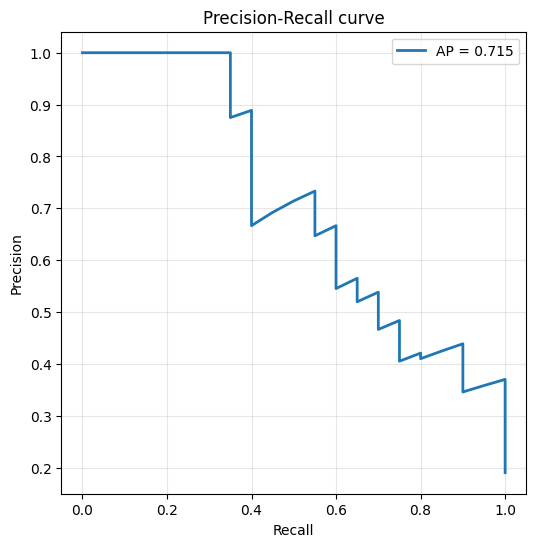

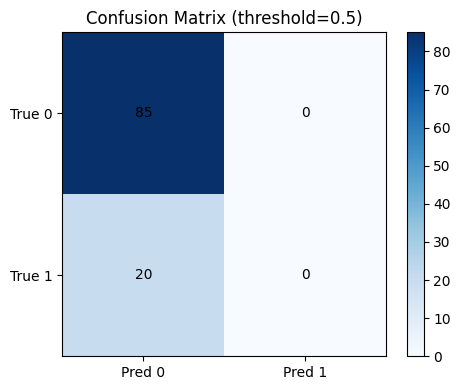

MAP: 100%|██████████| 1000/1000 [56:57<00:00,  3.42s/it, logpost=-25.8870, loglik=-25.8870, logprior=0.0000, ||grad||=0.0010, patience=0]  


{'mean_auc': 0.8378419905974086, 'std_auc': 0.06954742686617012, 'min_auc': np.float64(0.7333333333333333), 'max_auc': np.float64(0.95), 'n_folds': 5}


In [5]:
geometry = EuclideanGeometry(d=1, D=diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R1_p.pkl")

### Model $\mathbb{R}^2$

#### Without weigths

Multi_start (1)


MAP:  26%|██▌       | 6426/25000 [01:08<03:17, 94.17it/s, logpost=-22.2331, loglik=-20.2970, logprior=-1.9362, ||grad||=0.0127, patience=100] 


[STOP] Early stopping at iter 6425 (no improvement in 101 steps)

Best log-posterior: -22.2331


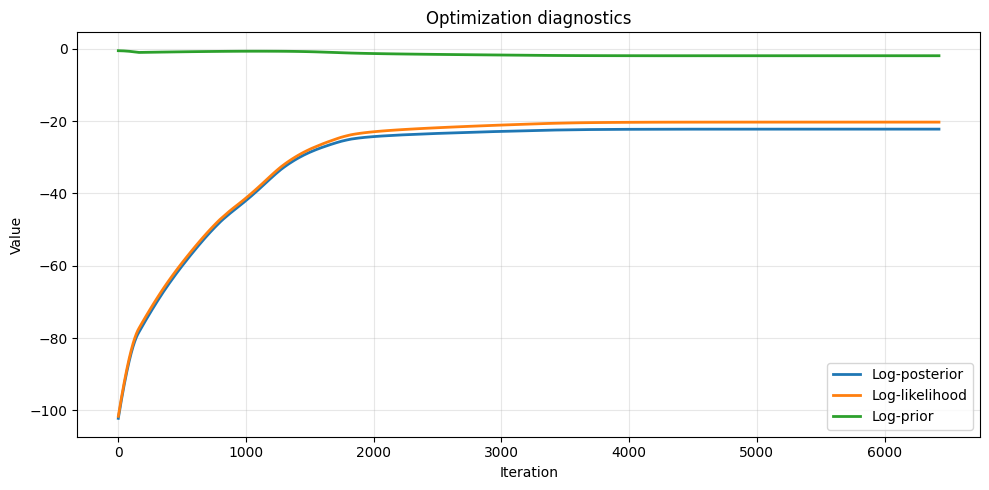

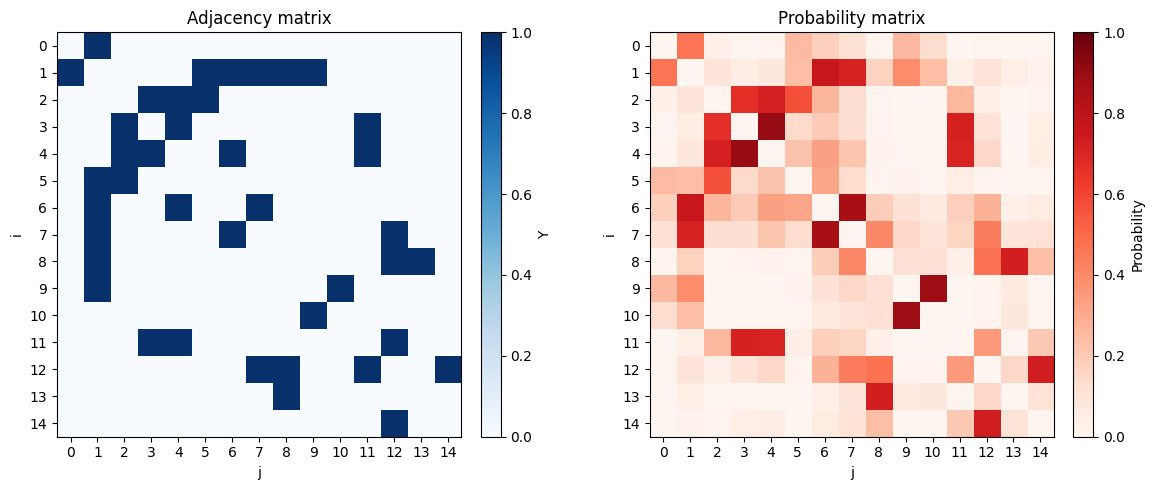

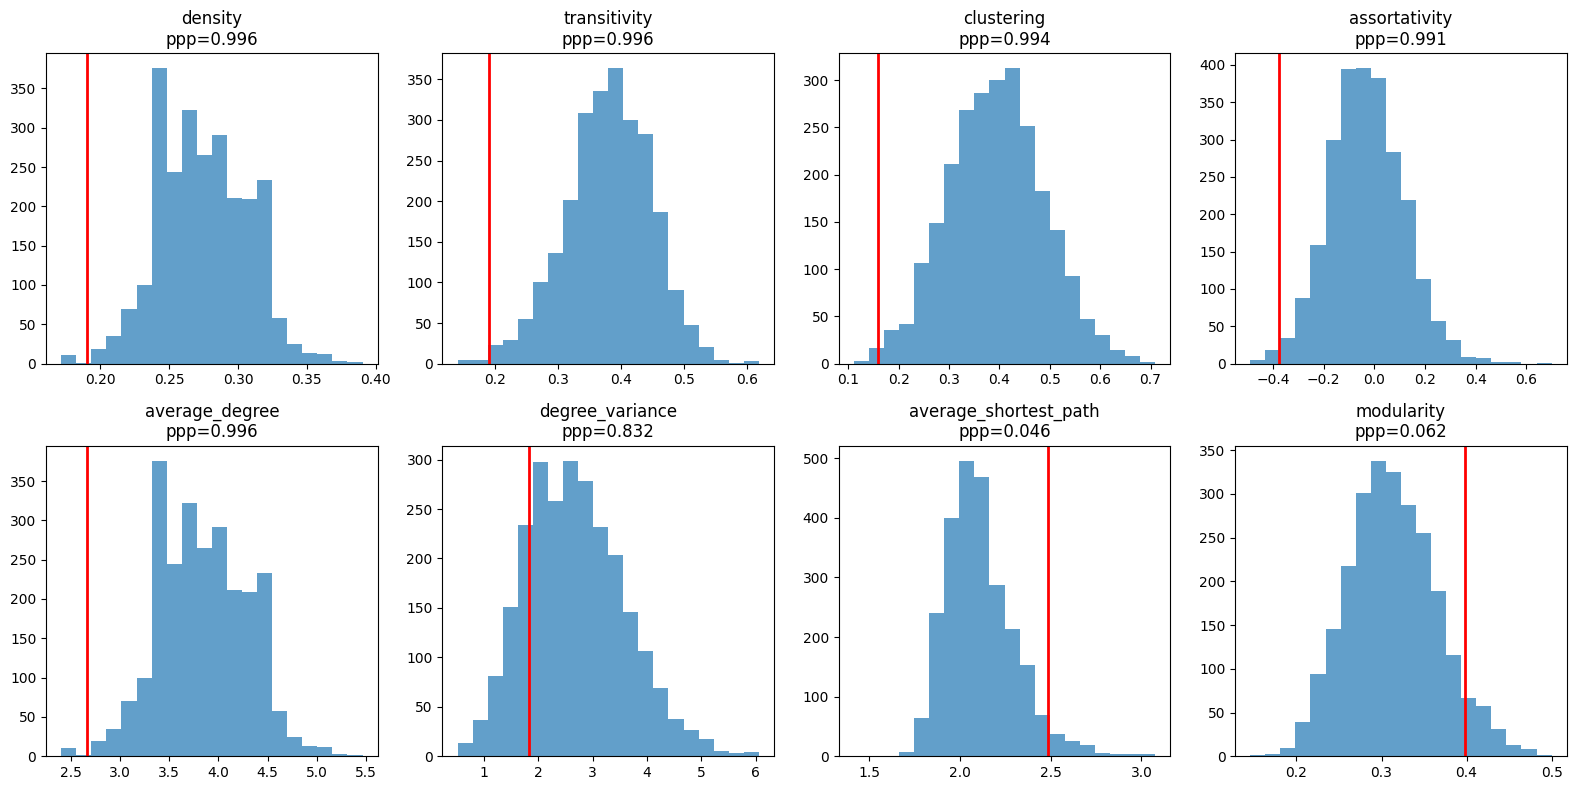

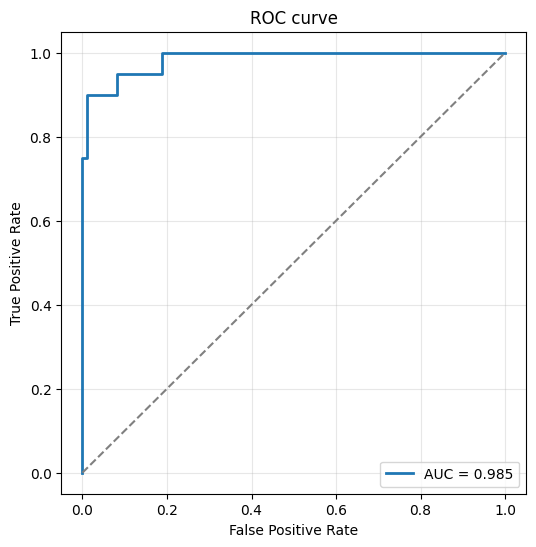

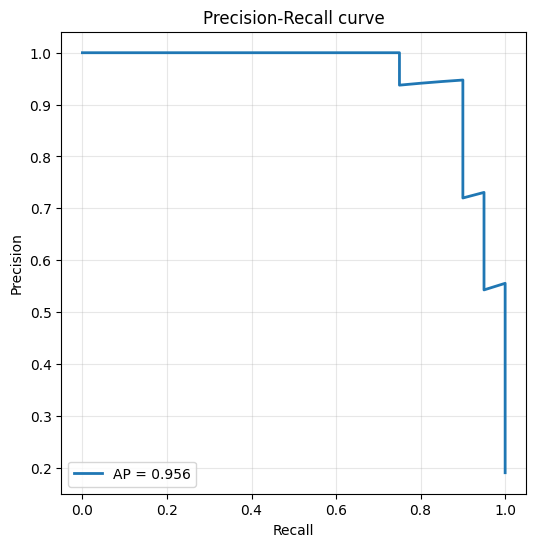

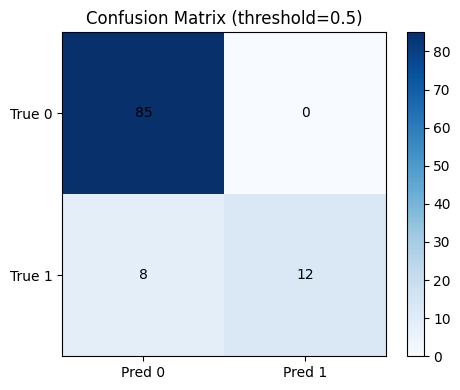

MAP: 100%|██████████| 1000/1000 [00:21<00:00, 47.17it/s, logpost=-11.9402, loglik=-10.3815, logprior=-1.5587, ||grad||=0.0120, patience=0]


{'mean_auc': 0.825940545808967, 'std_auc': 0.13353488444201267, 'min_auc': np.float64(0.6777777777777778), 'max_auc': np.float64(1.0), 'n_folds': 5}


In [51]:
geometry = EuclideanGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R2_c.pkl")

#### With weights

Multi_start (5)


MAP:  32%|███▏      | 8035/25000 [00:35<01:15, 225.69it/s, logpost=-19.1710, loglik=-19.1710, logprior=0.0000, ||grad||=0.0000, patience=100]


[STOP] Early stopping at iter 8034 (no improvement in 101 steps)


MAP:  32%|███▏      | 8035/25000 [00:32<01:09, 244.91it/s, logpost=-19.1710, loglik=-19.1710, logprior=0.0000, ||grad||=0.0000, patience=100]


[STOP] Early stopping at iter 8034 (no improvement in 101 steps)


...

[STOP] Early stopping at iter 8034 (no improvement in 101 steps)


MAP:  32%|███▏      | 8035/25000 [01:02<02:12, 128.33it/s, logpost=-19.1710, loglik=-19.1710, logprior=0.0000, ||grad||=0.0000, patience=100]


[STOP] Early stopping at iter 8034 (no improvement in 101 steps)


MAP:  32%|███▏      | 8035/25000 [00:30<01:04, 262.73it/s, logpost=-19.1710, loglik=-19.1710, logprior=0.0000, ||grad||=0.0000, patience=100]


[STOP] Early stopping at iter 8034 (no improvement in 101 steps)

Best log-posterior: -19.1710


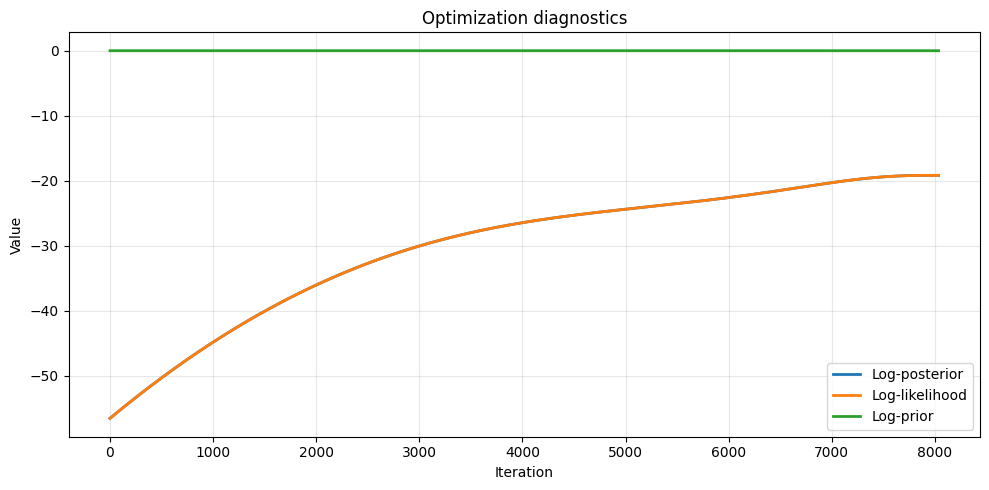

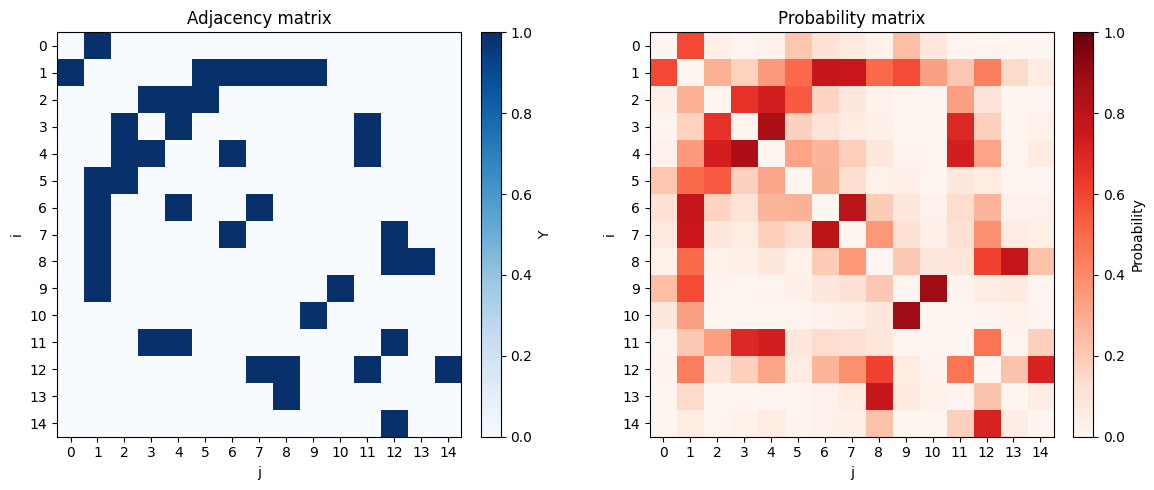

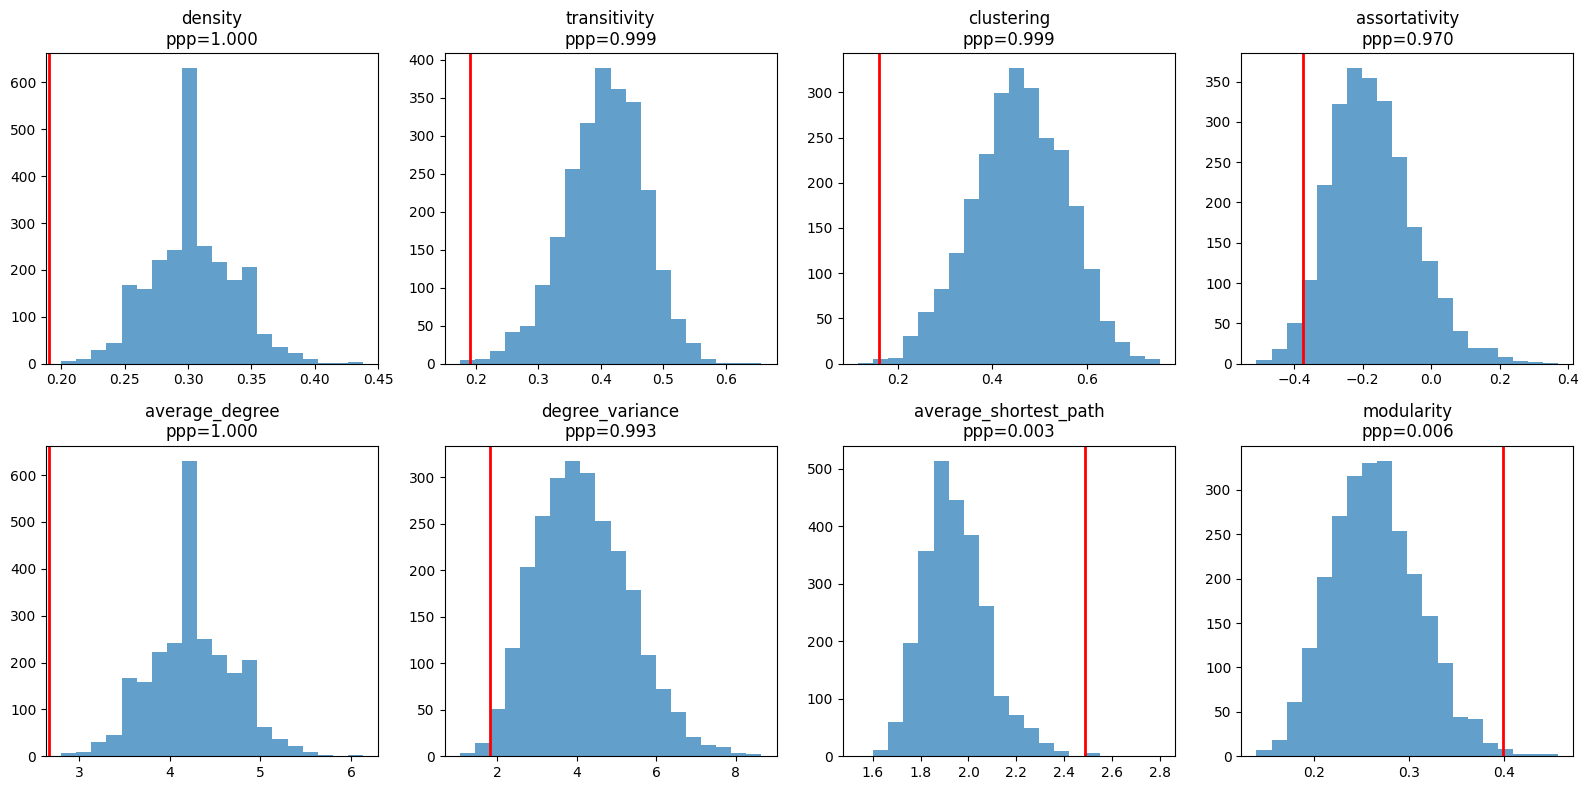

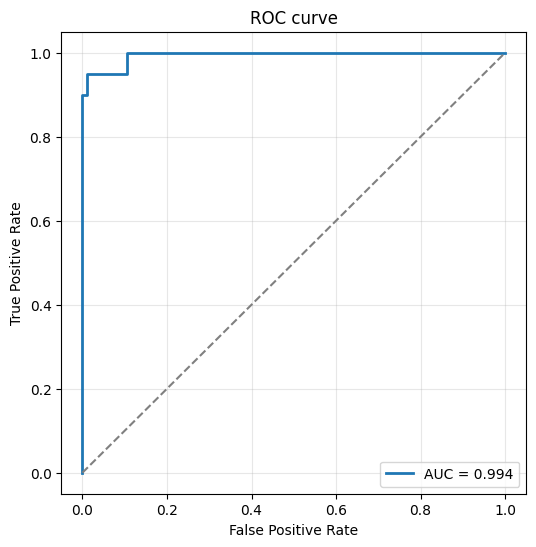

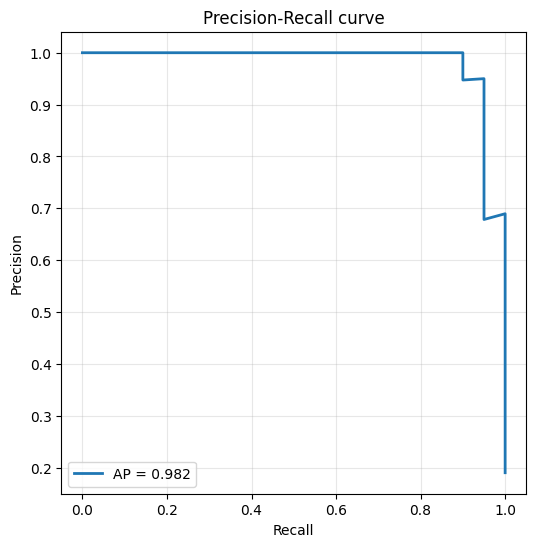

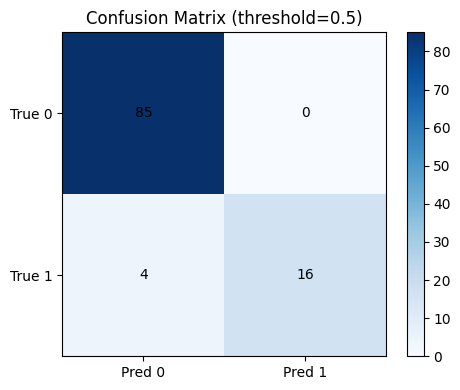

MAP:  75%|███████▍  | 748/1000 [00:03<00:01, 208.32it/s, logpost=-12.6200, loglik=-12.6200, logprior=0.0000, ||grad||=0.0000, patience=49]


{'mean_auc': 0.9553921568627451, 'std_auc': 0.03171046230544311, 'min_auc': np.float64(0.9222222222222223), 'max_auc': np.float64(1.0), 'n_folds': 5}


In [7]:
geometry = EuclideanGeometry(d=2, D = diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R2_p.pkl")

### Model $\mathbb{R}^3$

#### Without weights

Multi_start (1)


MAP:  89%|████████▉ | 22228/25000 [02:42<00:20, 136.94it/s, logpost=-20.2460, loglik=-17.6527, logprior=-2.5933, ||grad||=0.0127, patience=100]


[STOP] Early stopping at iter 22227 (no improvement in 101 steps)

Best log-posterior: -20.2460


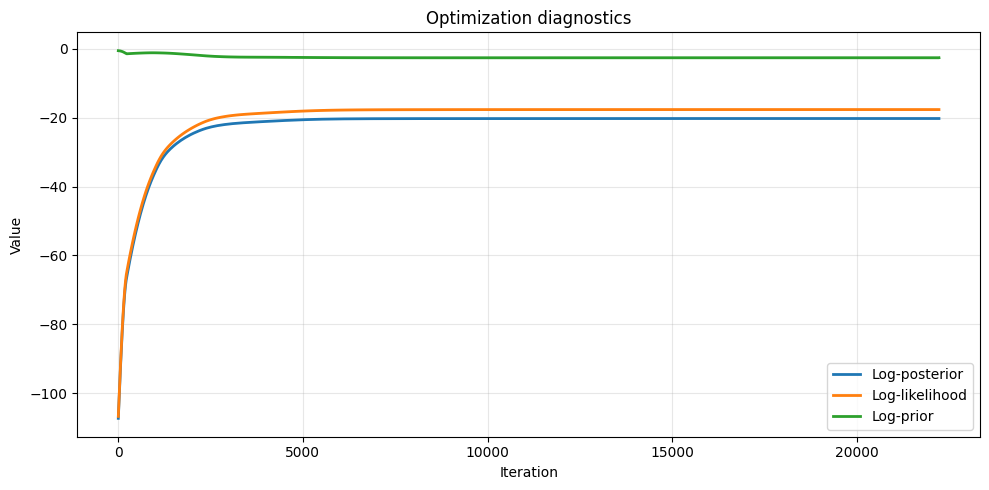

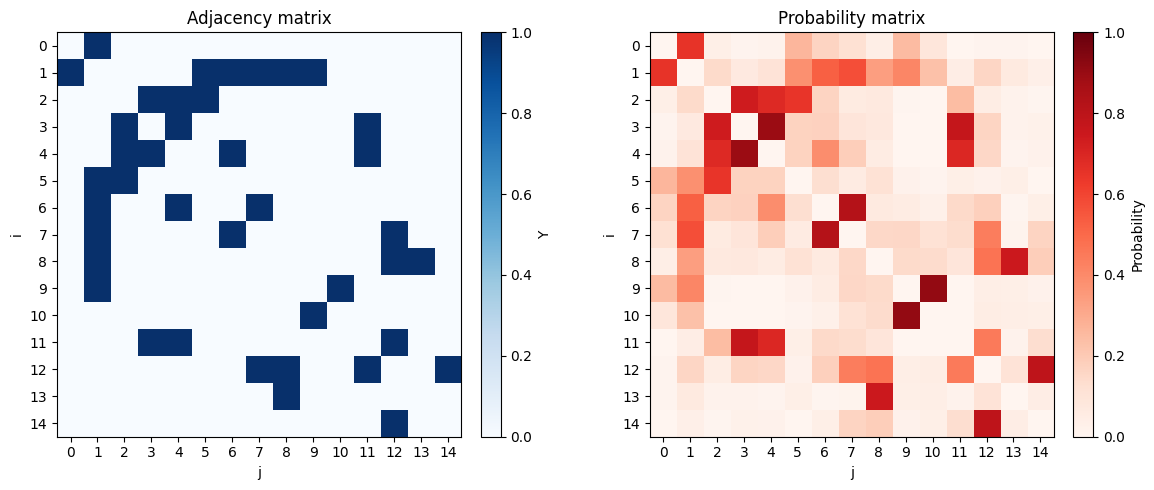

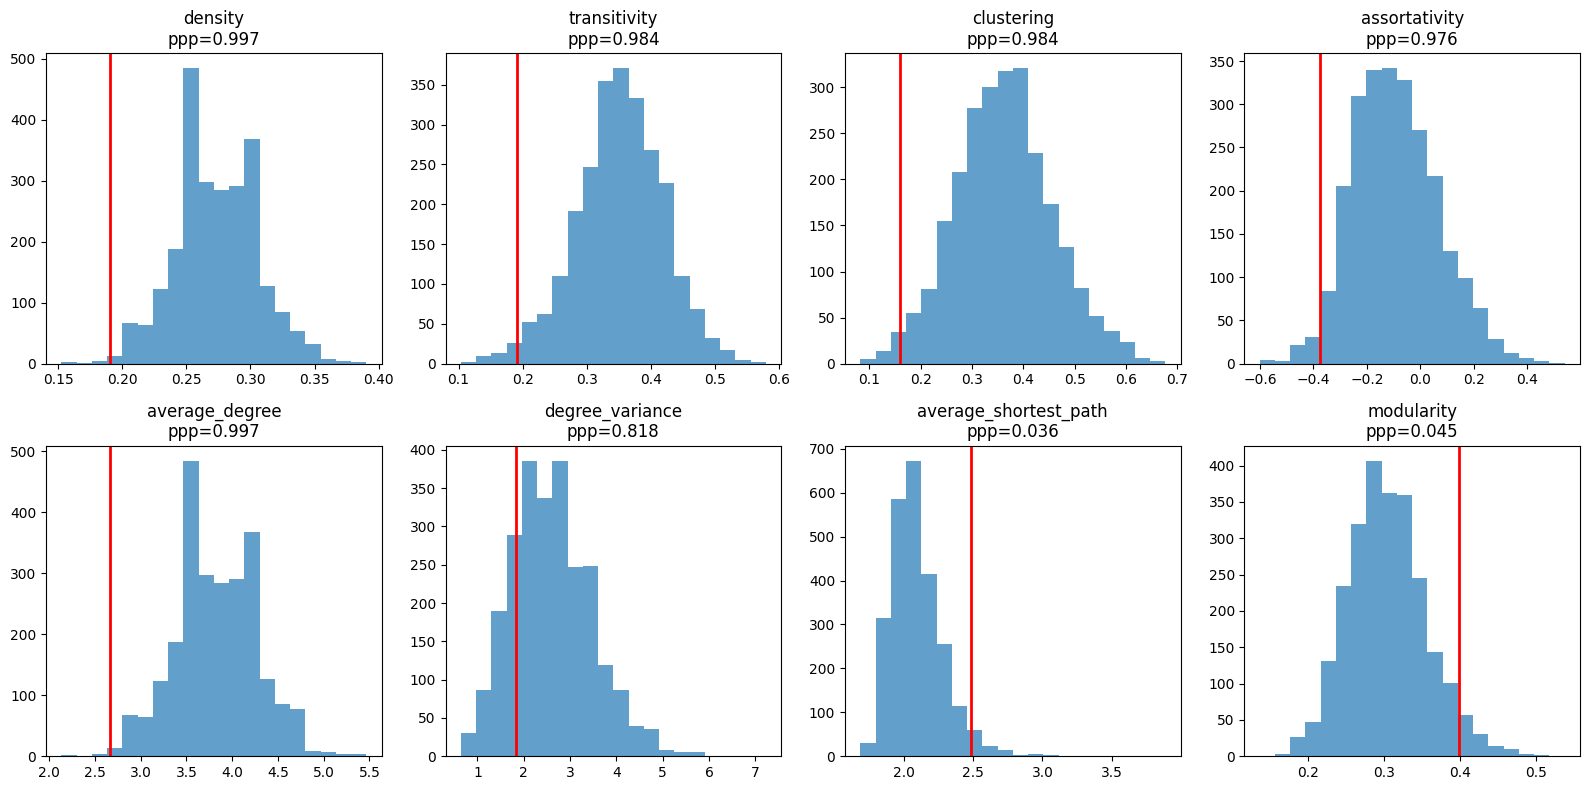

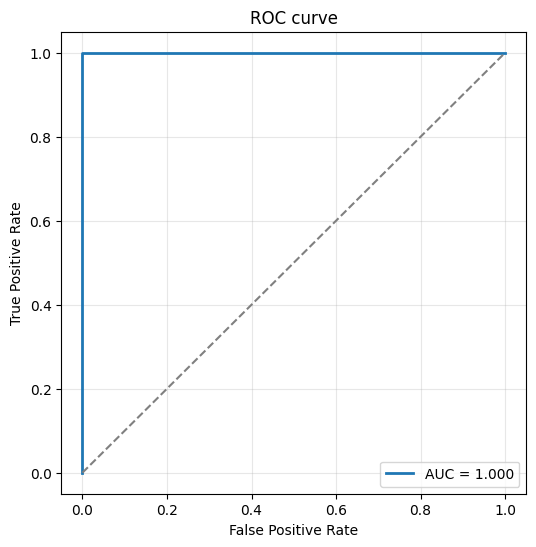

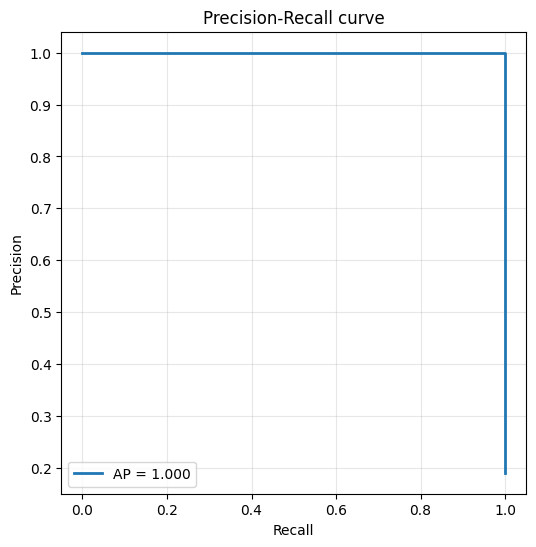

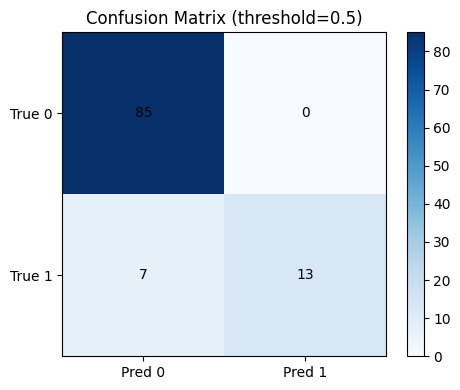

MAP: 100%|██████████| 1000/1000 [00:07<00:00, 130.80it/s, logpost=-10.7585, loglik=-8.7780, logprior=-1.9805, ||grad||=0.0118, patience=0]


{'mean_auc': 0.7703594771241831, 'std_auc': 0.12853741734506136, 'min_auc': np.float64(0.6323529411764706), 'max_auc': np.float64(1.0), 'n_folds': 5}


In [48]:
geometry = EuclideanGeometry(d=3, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R3_c.pkl")

#### With weights

Multi_start (1)


MAP:   4%|▎         | 876/25000 [00:05<02:22, 169.07it/s, logpost=-16.1452, loglik=-16.1452, logprior=0.0000, ||grad||=0.0079, patience=100]


[STOP] Early stopping at iter 875 (no improvement in 101 steps)

Best log-posterior: -16.1452


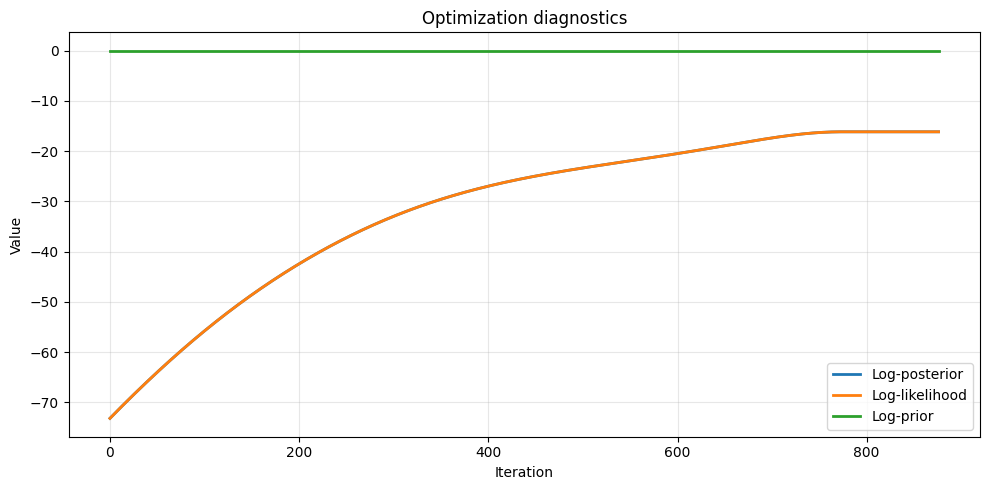

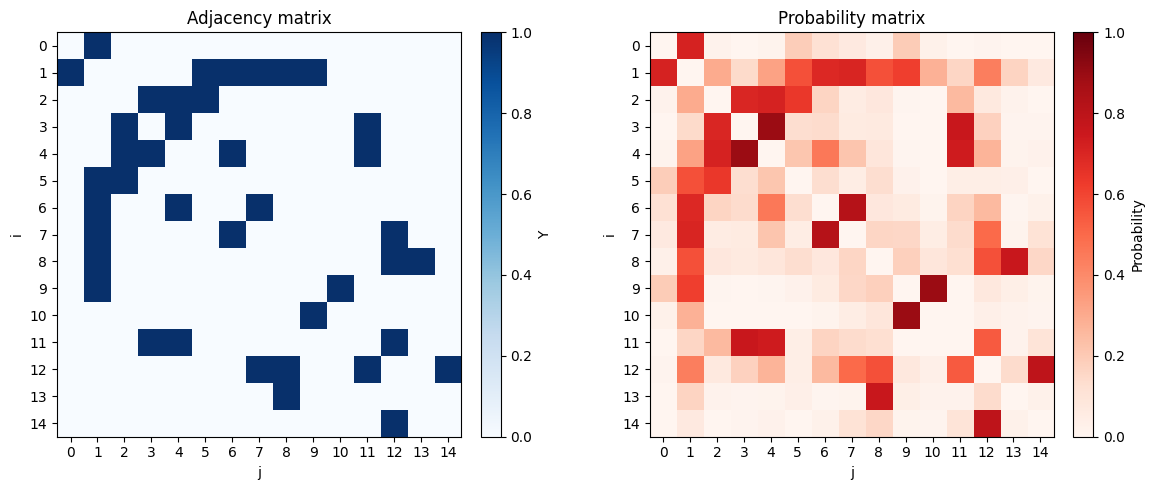

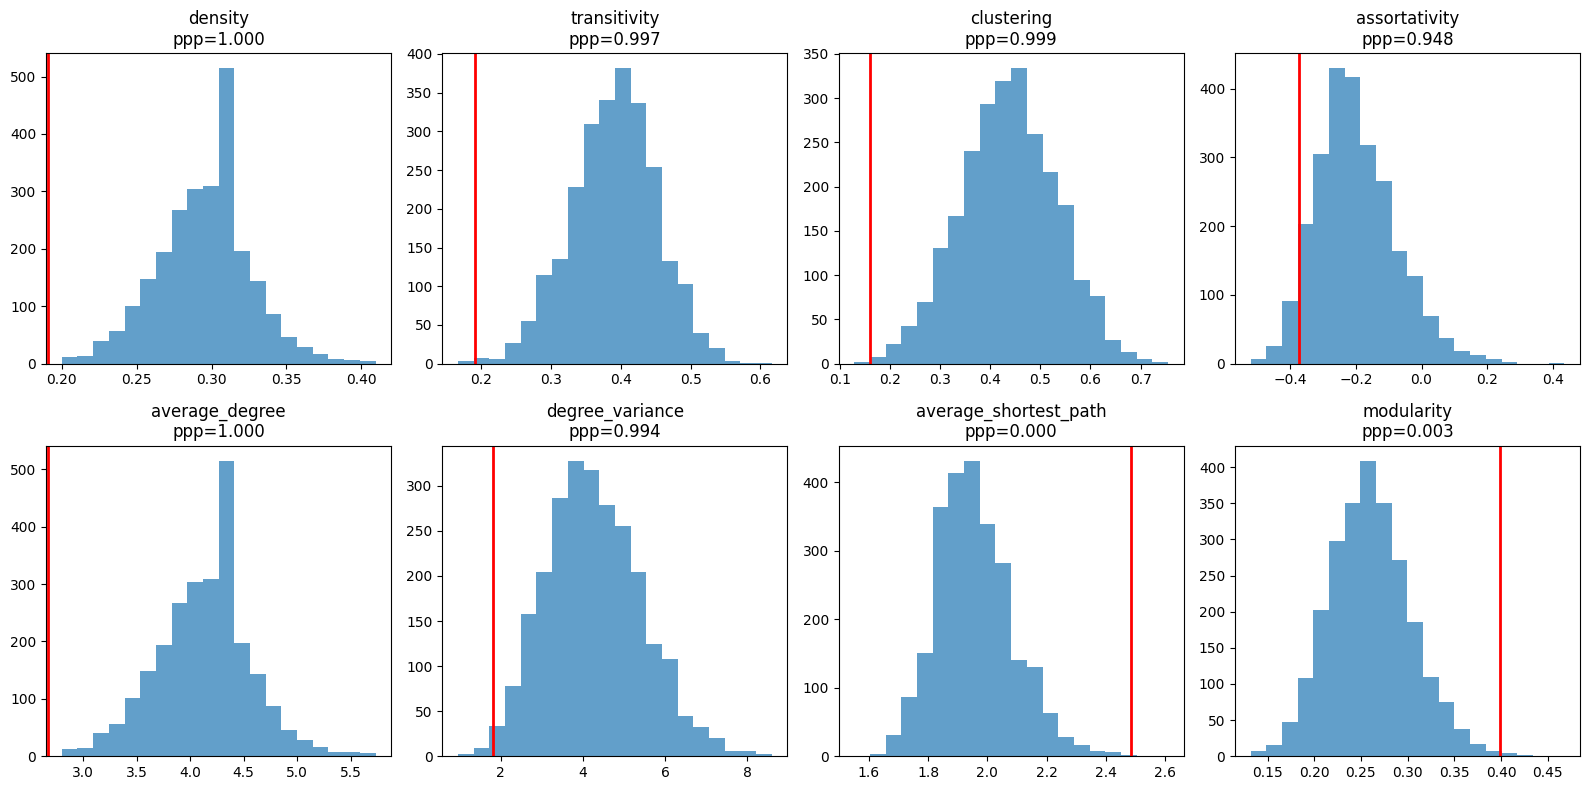

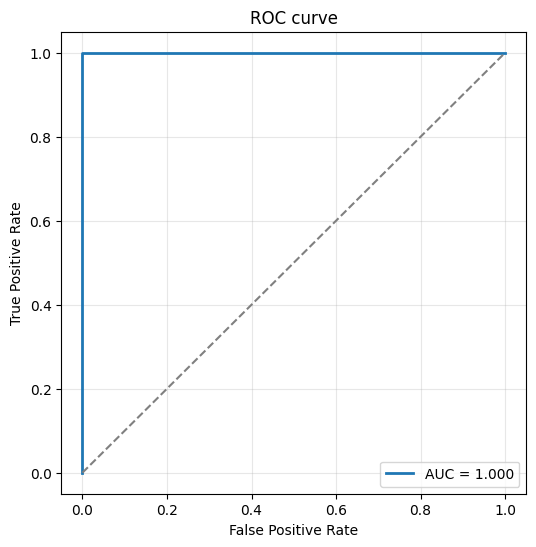

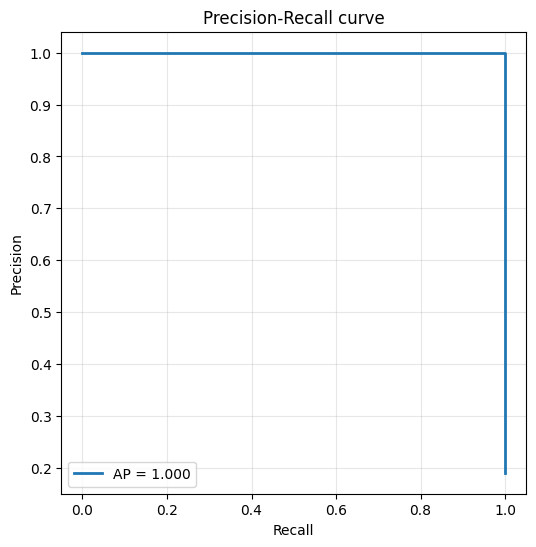

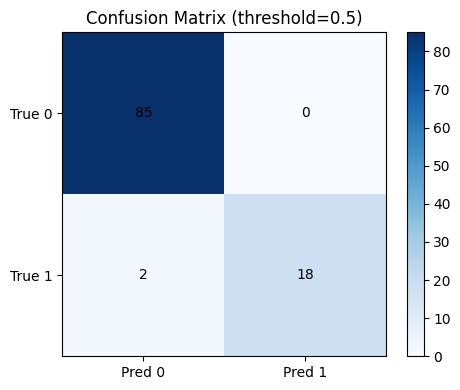

MAP:   9%|▉         | 91/1000 [00:01<00:11, 76.09it/s, logpost=-10.8963, loglik=-10.8963, logprior=0.0000, ||grad||=0.0075, patience=49] 


{'mean_auc': 0.9836764705882353, 'std_auc': 0.020101386617460925, 'min_auc': np.float64(0.9558823529411764), 'max_auc': np.float64(1.0), 'n_folds': 5}


In [49]:
geometry = EuclideanGeometry(d=3, D = diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R3_p.pkl")

## Models over $\mathbb{S}^d$

### Model $\mathbb{S}^1$

#### Without weights

In [43]:
with open("Florentine_R2_c.pkl", "rb") as f:
    results_R1_c = pickle.load(f)

Z_init = np.zeros((15,2))
Z_init[:,:] = np.asarray(results_R1_c['latent_params']['Z'])
for i in range(15):
    Z_init[i] = geometry.project_to_domain(Z_init[i])

Multi_start (1)


MAP:   8%|▊         | 1986/25000 [00:15<03:05, 124.32it/s, logpost=-35.3868, loglik=-34.1280, logprior=-1.2588, ||grad||=0.0123, patience=100]


[STOP] Early stopping at iter 1985 (no improvement in 101 steps)

Best log-posterior: -35.3868


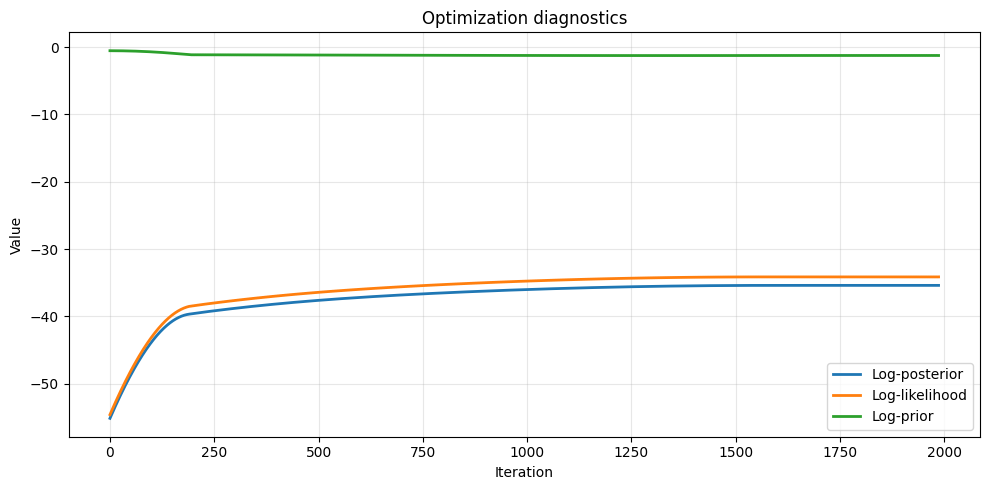

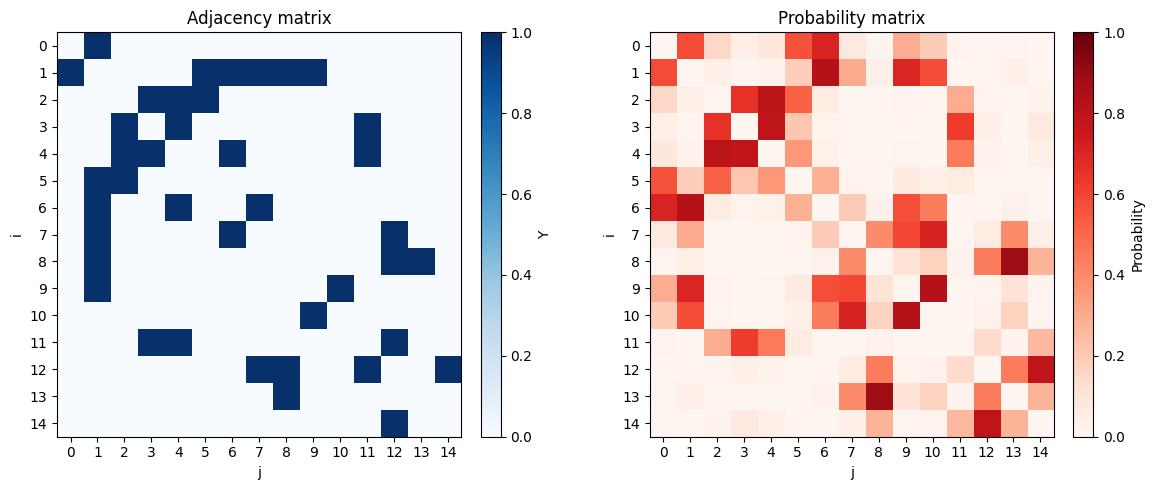

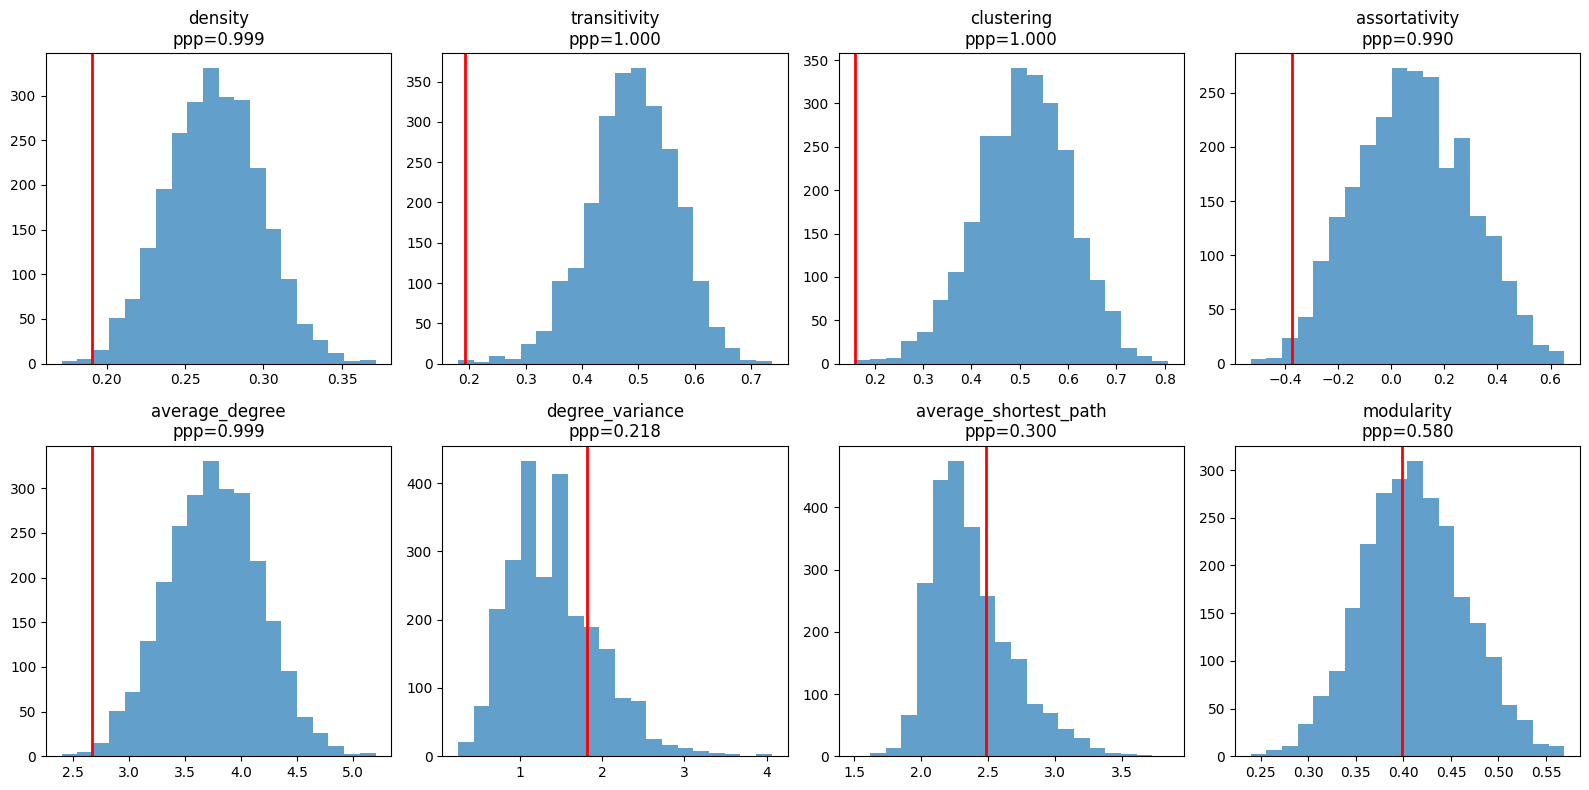

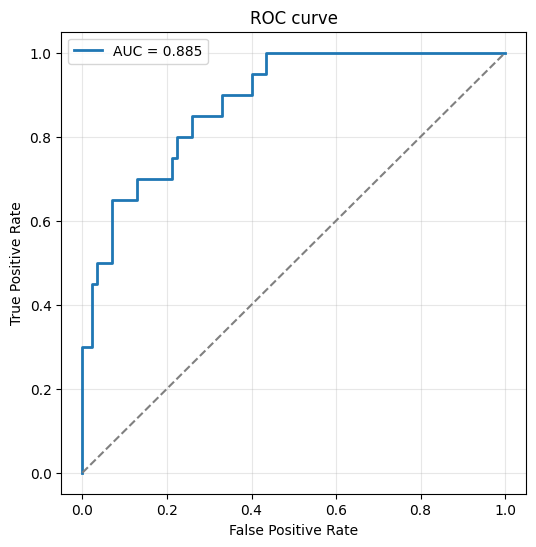

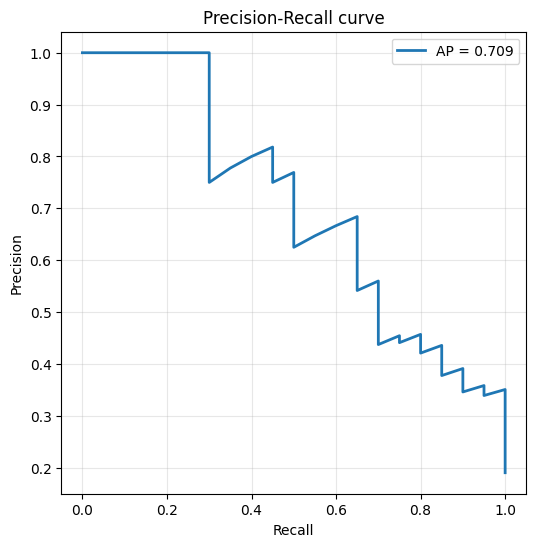

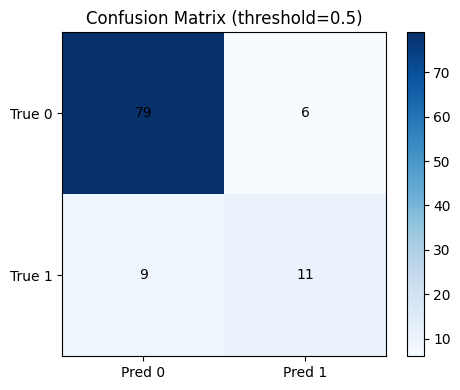

MAP: 100%|██████████| 1000/1000 [00:07<00:00, 134.90it/s, logpost=-21.0666, loglik=-20.0063, logprior=-1.0602, ||grad||=0.0119, patience=0]


{'mean_auc': 0.7629159500057333, 'std_auc': 0.11545343001090788, 'min_auc': np.float64(0.6555555555555556), 'max_auc': np.float64(0.9473684210526316), 'n_folds': 5}


In [ ]:
geometry = SphericalGeometry(d=1, D=diam)
with open("Florentine_R2_c.pkl", "rb") as f:
    results_R2_c = pickle.load(f)
Z_init = np.zeros((15,2))
Z_init[:,:] = np.asarray(results_R2_c['latent_params']['Z'])
for i in range(15):
    Z_init[i] = geometry.project_to_domain(Z_init[i])
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S1_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:   3%|▎         | 833/25000 [00:04<02:20, 171.53it/s, logpost=-23.3160, loglik=-23.3160, logprior=0.0000, ||grad||=0.0069, patience=100]


[STOP] Early stopping at iter 832 (no improvement in 101 steps)

Best log-posterior: -23.3160


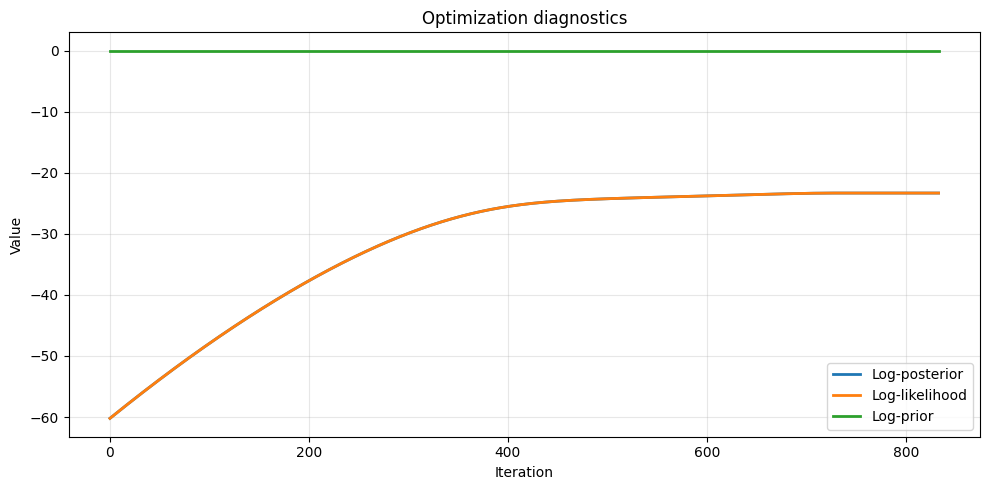

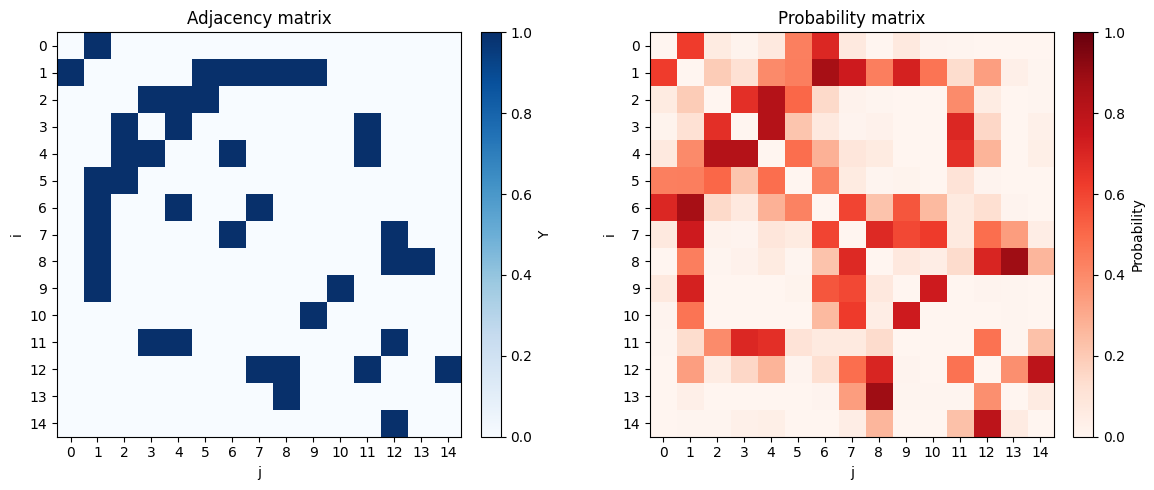

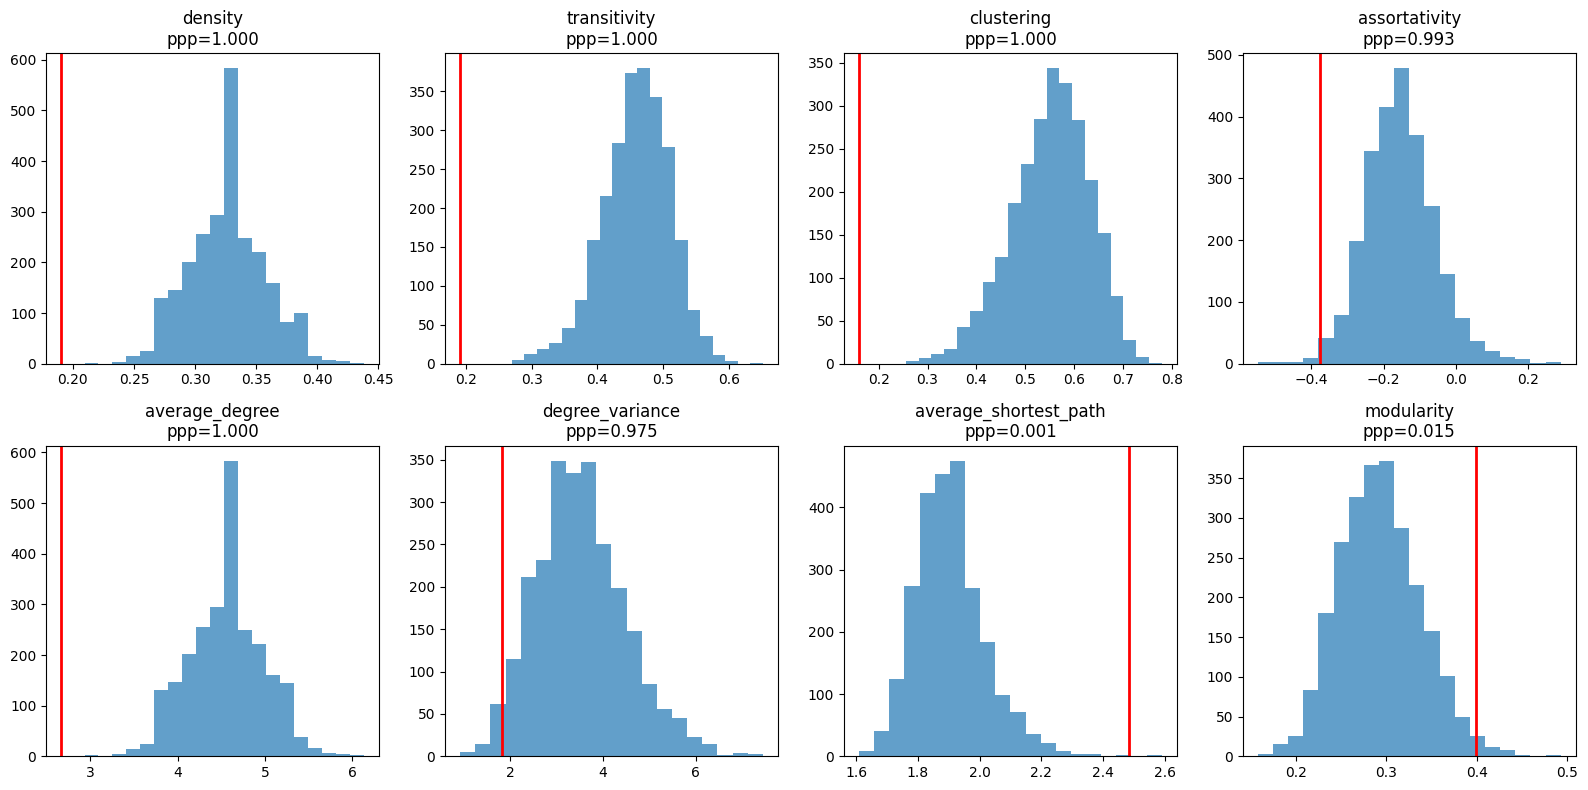

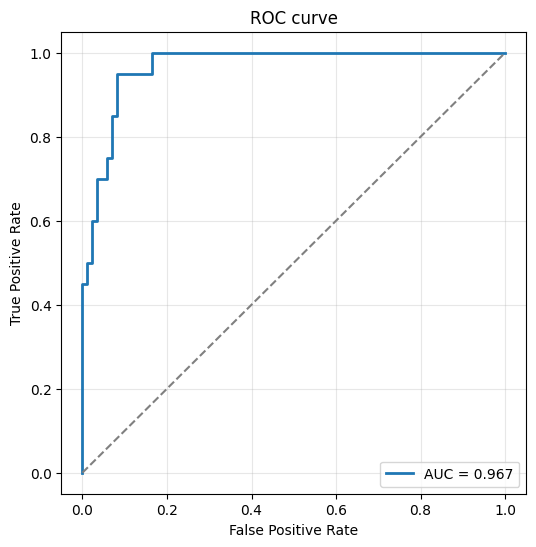

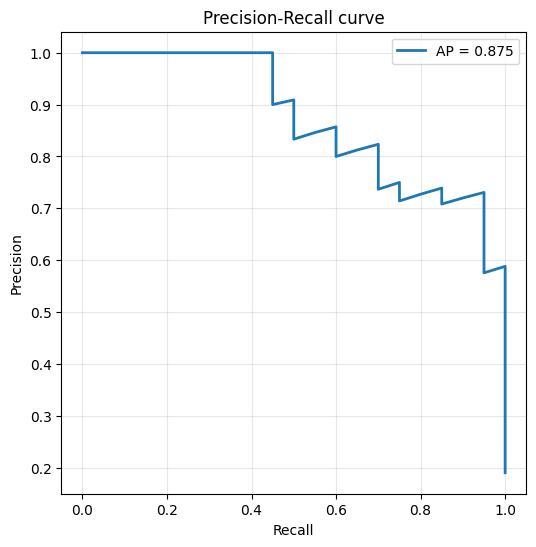

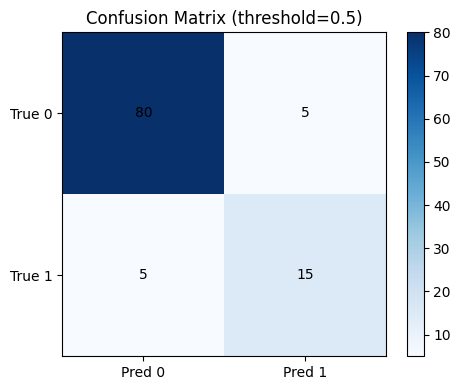

MAP:  19%|█▉        | 190/1000 [00:01<00:06, 119.84it/s, logpost=-15.4223, loglik=-15.4223, logprior=0.0000, ||grad||=0.0055, patience=49]


{'mean_auc': 0.8858714596949891, 'std_auc': 0.08150492189020375, 'min_auc': np.float64(0.7666666666666666), 'max_auc': np.float64(1.0), 'n_folds': 5}


In [47]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S1_p.pkl")

### Model $\mathbb{S}^2$

#### Without weights

In [53]:
with open("Florentine_R3_p.pkl", "rb") as f:
    results_R3_p = pickle.load(f)

Z_init = np.zeros((n,3))
Z_init[:,:] = np.asarray(results_R3_p['latent_params']['Z'])

Multi_start (1)


MAP:  20%|█▉        | 4952/25000 [00:37<02:29, 133.74it/s, logpost=-23.7199, loglik=-22.0655, logprior=-1.6543, ||grad||=0.0090, patience=100]


[STOP] Early stopping at iter 4951 (no improvement in 101 steps)

Best log-posterior: -23.7199


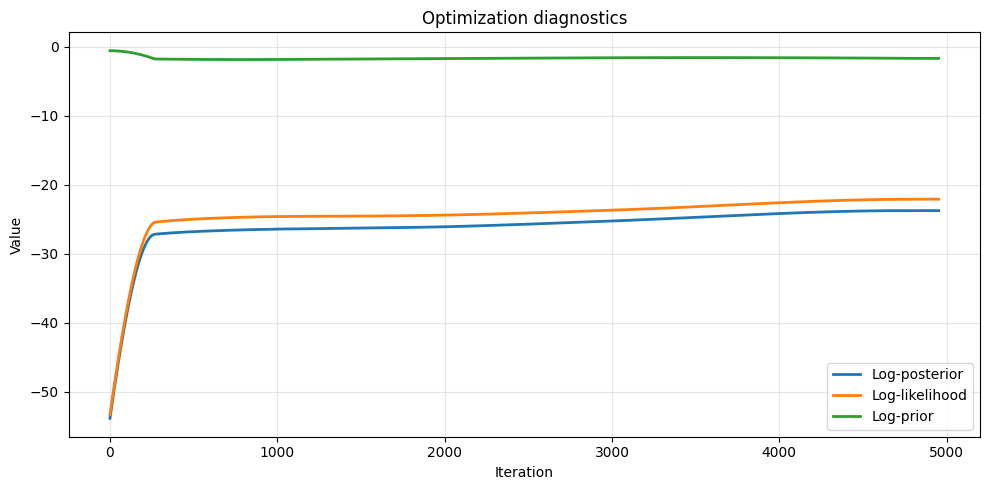

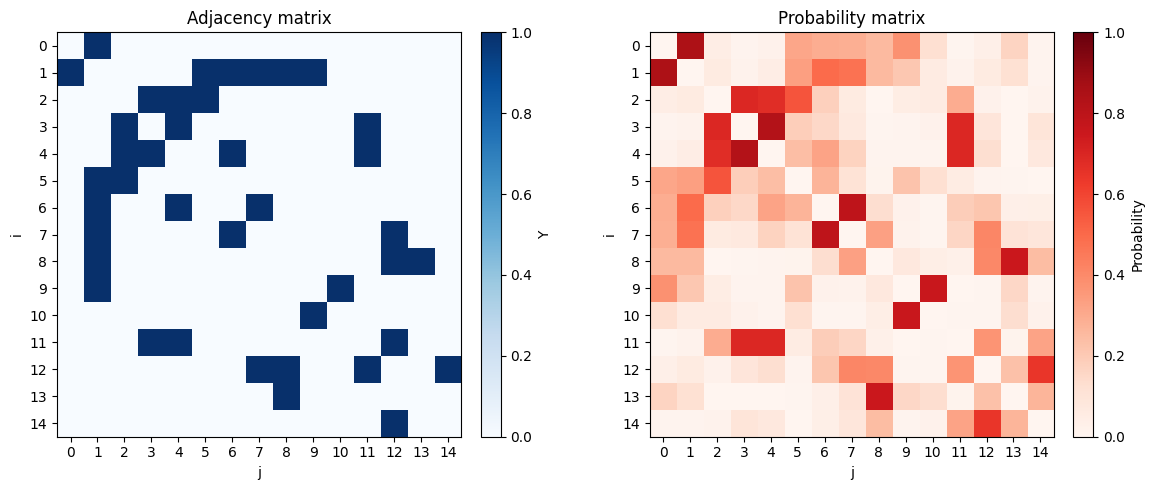

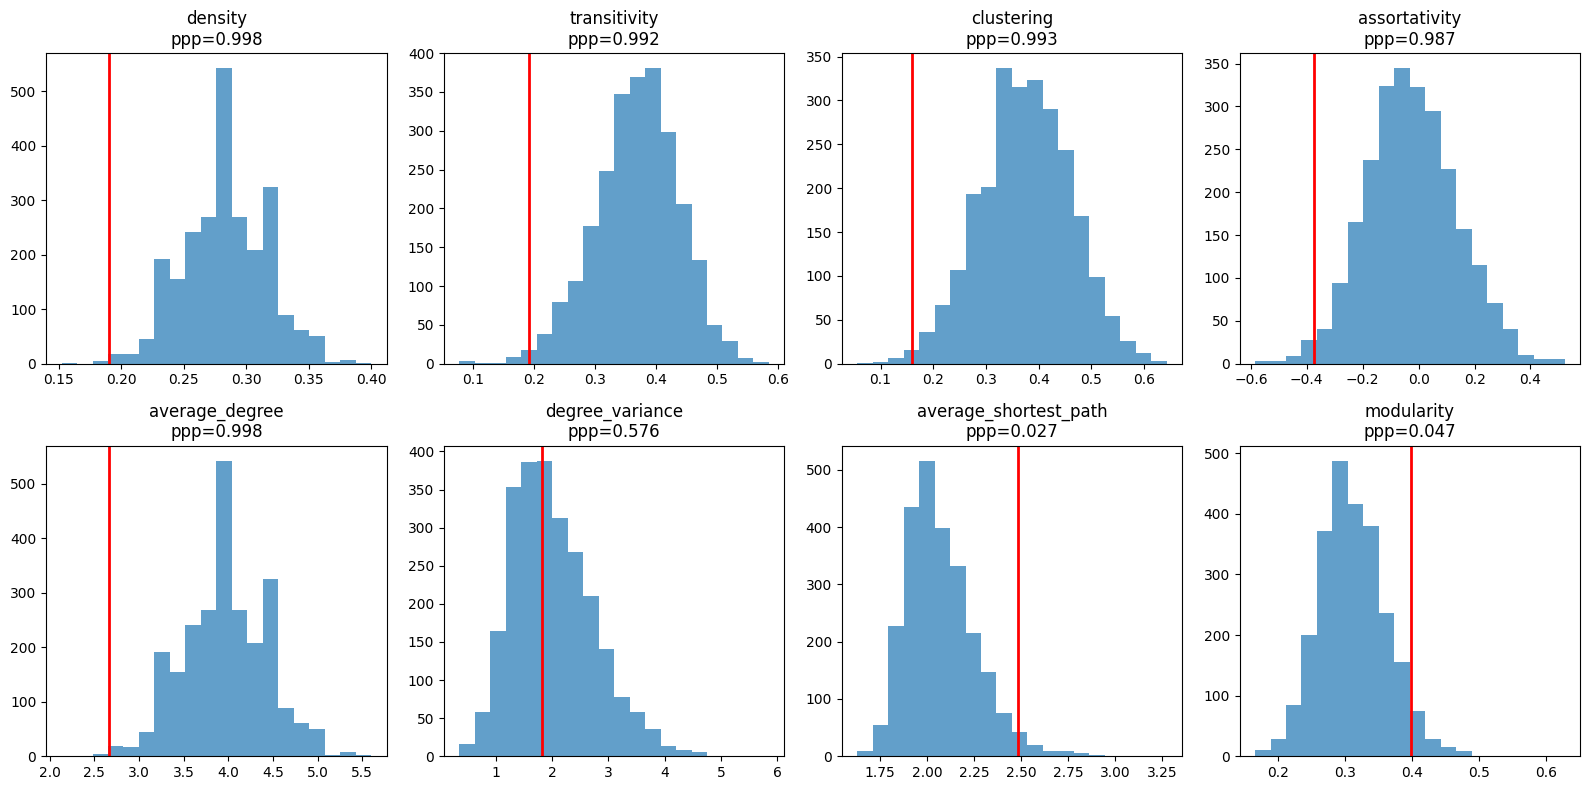

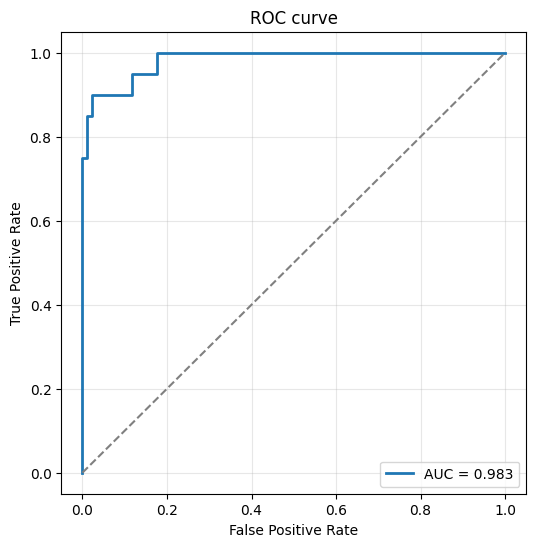

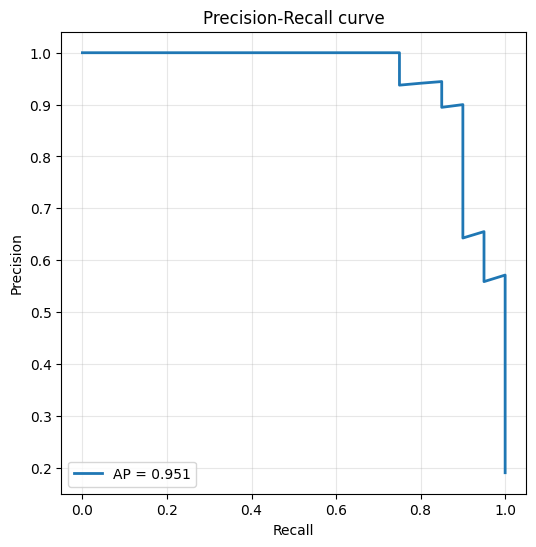

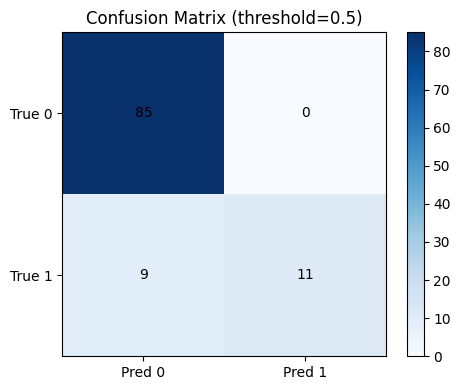

MAP: 100%|██████████| 1000/1000 [00:07<00:00, 131.62it/s, logpost=-12.9540, loglik=-11.6949, logprior=-1.2591, ||grad||=0.0120, patience=0]


{'mean_auc': 0.7975914459350992, 'std_auc': 0.047460352578339346, 'min_auc': np.float64(0.7555555555555555), 'max_auc': np.float64(0.8823529411764706), 'n_folds': 5}


In [55]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S2_c.pkl")


alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:   4%|▎         | 880/25000 [00:05<02:23, 168.15it/s, logpost=-18.2493, loglik=-18.2493, logprior=0.0000, ||grad||=0.0067, patience=100]


[STOP] Early stopping at iter 879 (no improvement in 101 steps)

Best log-posterior: -18.2493


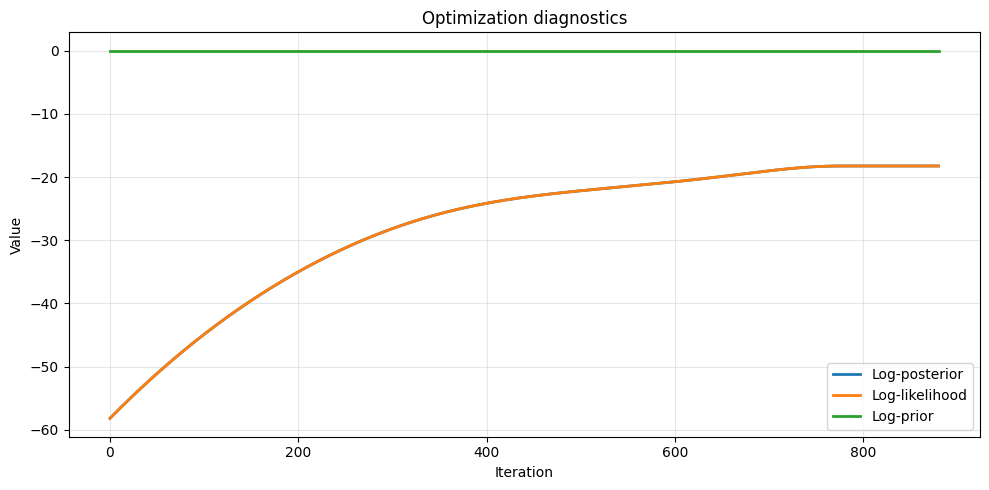

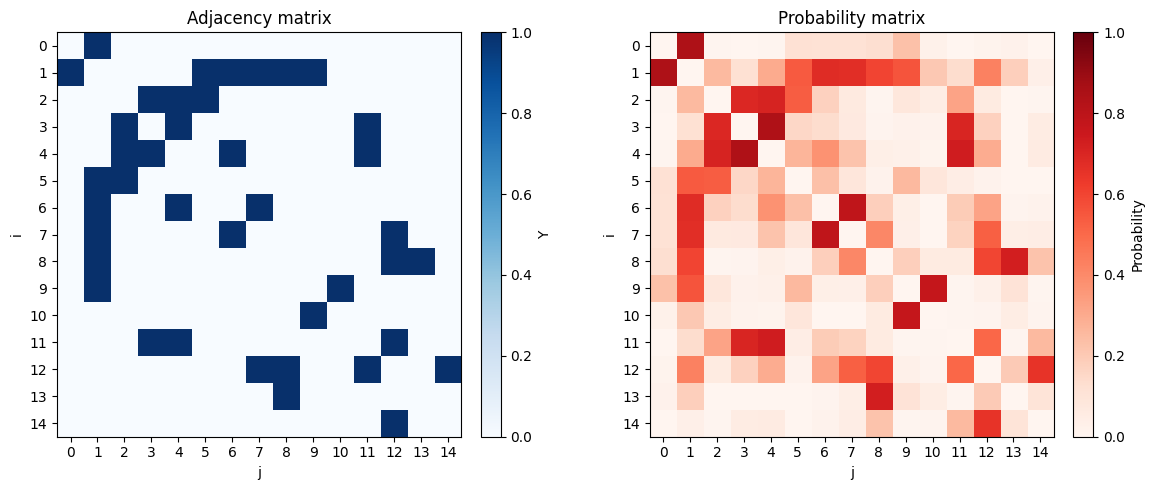

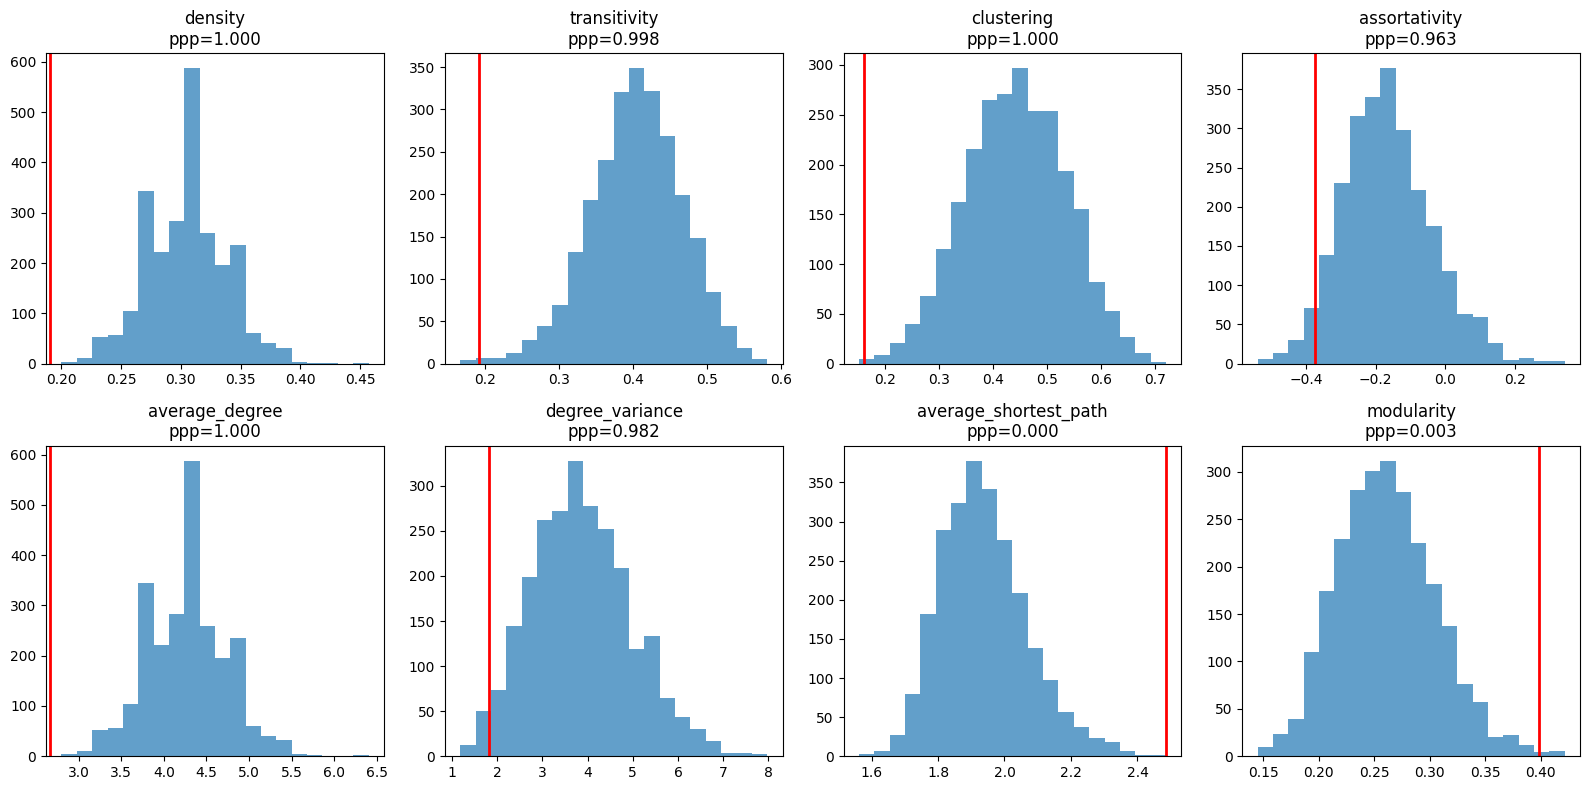

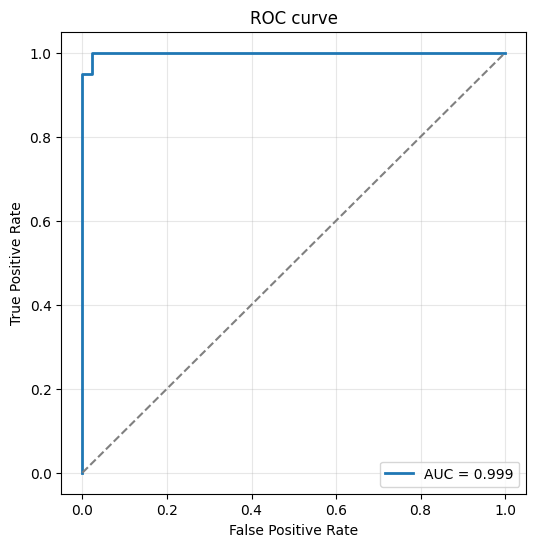

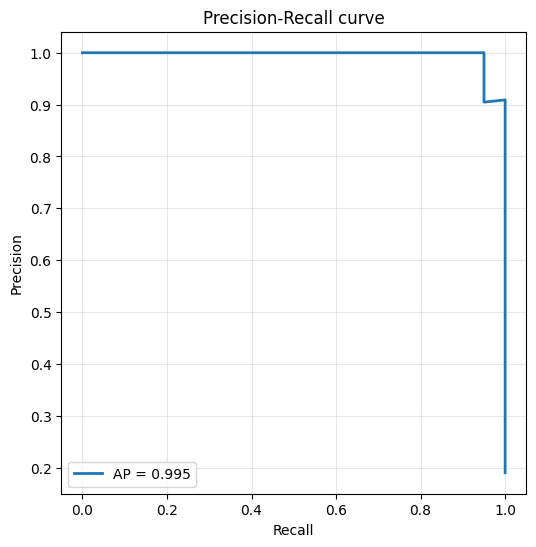

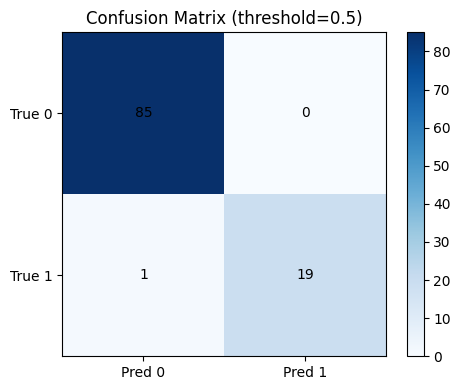

MAP:  12%|█▏        | 123/1000 [00:01<00:09, 93.56it/s, logpost=-12.3445, loglik=-12.3445, logprior=0.0000, ||grad||=0.0063, patience=49] 


{'mean_auc': 0.980648148148148, 'std_auc': 0.016729306157139762, 'min_auc': np.float64(0.9625), 'max_auc': np.float64(1.0), 'n_folds': 5}


In [56]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S2_p.pkl")

## Models over $\mathbb{H}^d$

### Model $\mathbb{H}^1$

#### Without weights

In [151]:
with open("Florentine_R1_c.pkl", "rb") as f:
    results_R1_c = pickle.load(f)

Z_init = np.zeros((15,2))
Z_init[:,0:1] = np.asarray(results_R1_c['latent_params']['Z'])
for i in range(15):
    Z_init[i] = geometry.project_to_domain(Z_init[i])

Multi_start (1)


MAP:   1%|          | 296/25000 [00:02<03:43, 110.42it/s, logpost=-70.6392, loglik=-70.0893, logprior=-0.5499, ||grad||=0.0133, patience=100]


[STOP] Early stopping at iter 295 (no improvement in 101 steps)

Best log-posterior: -70.6392


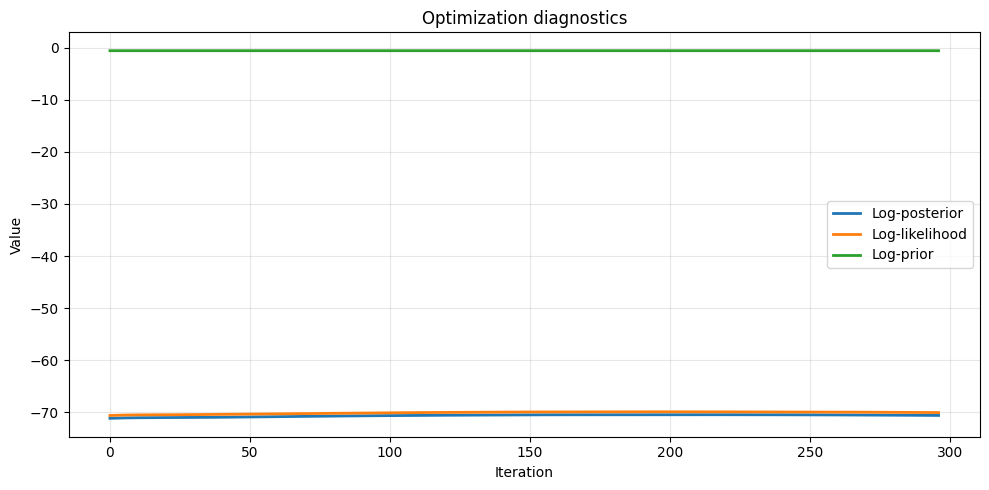

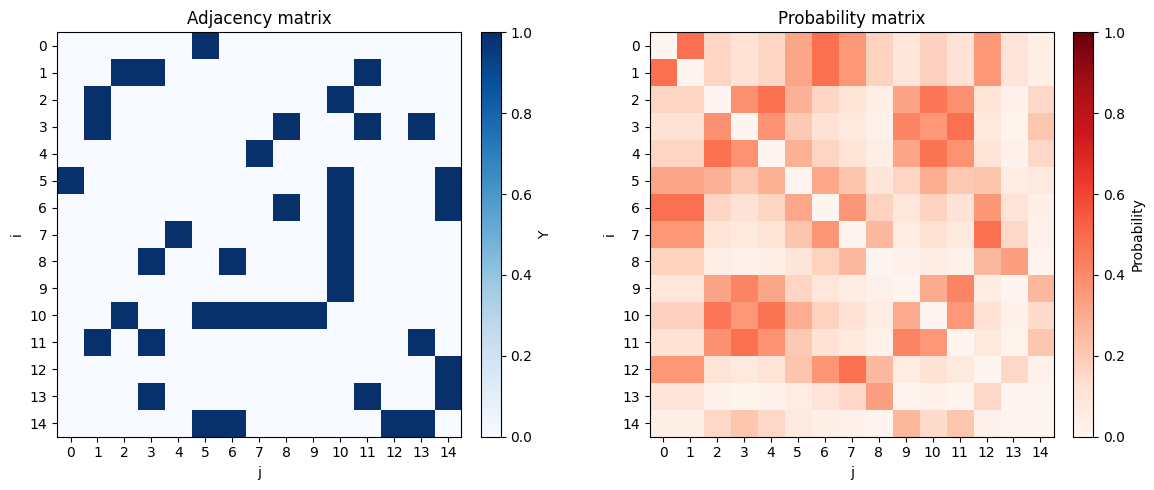

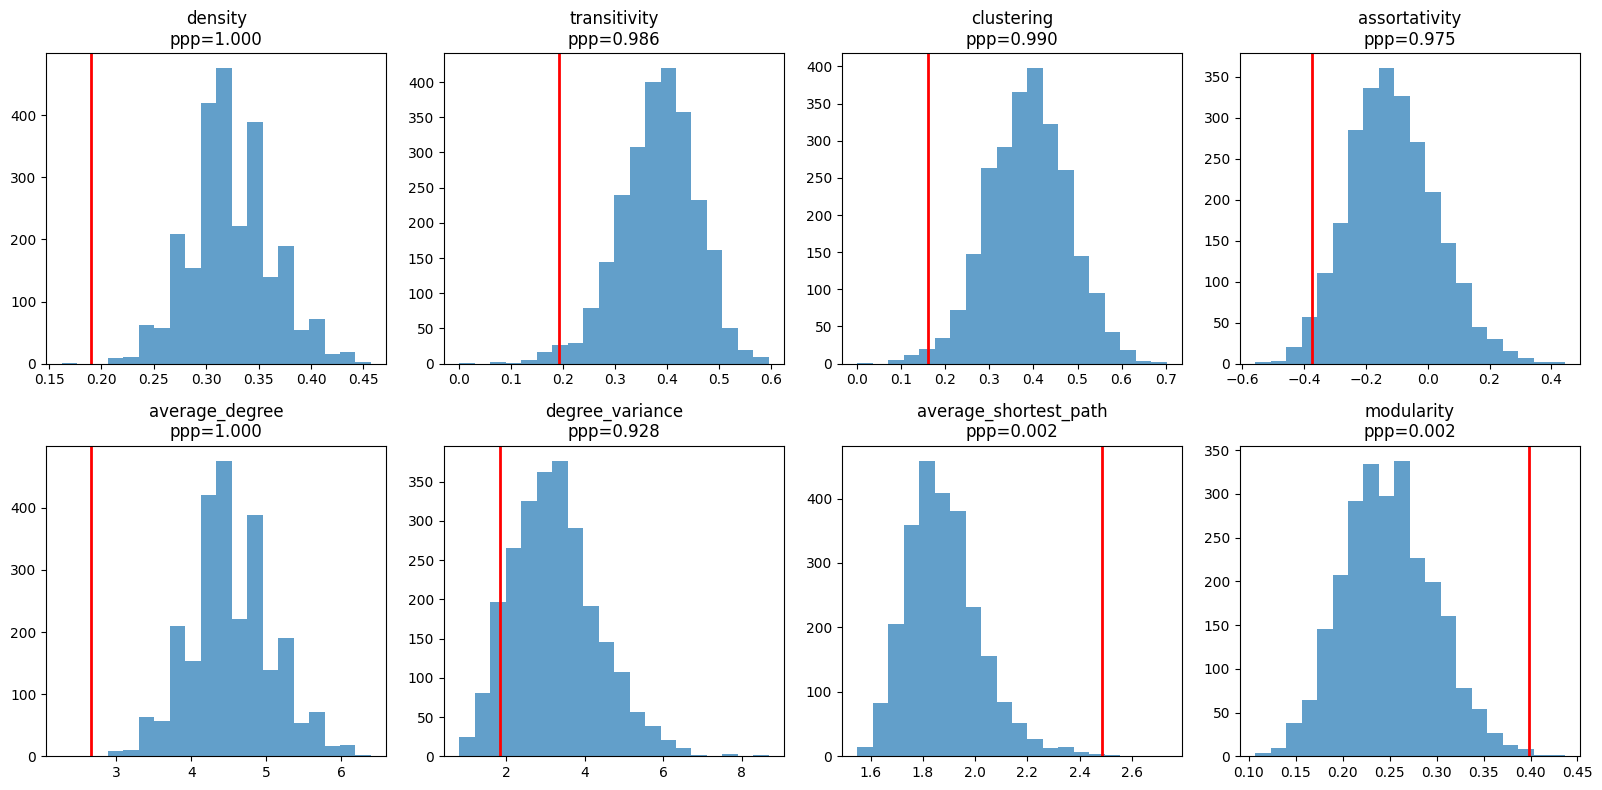

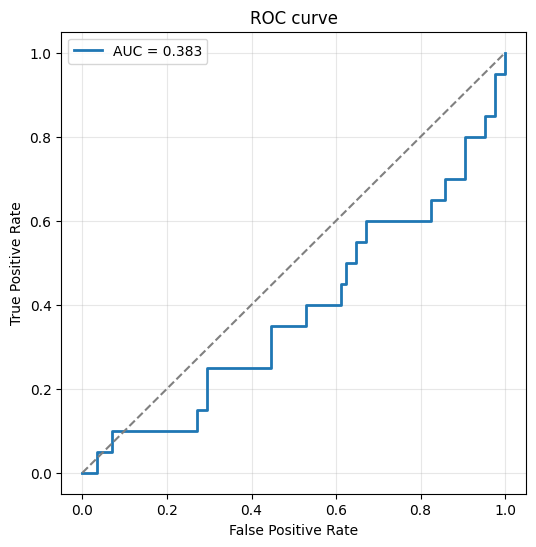

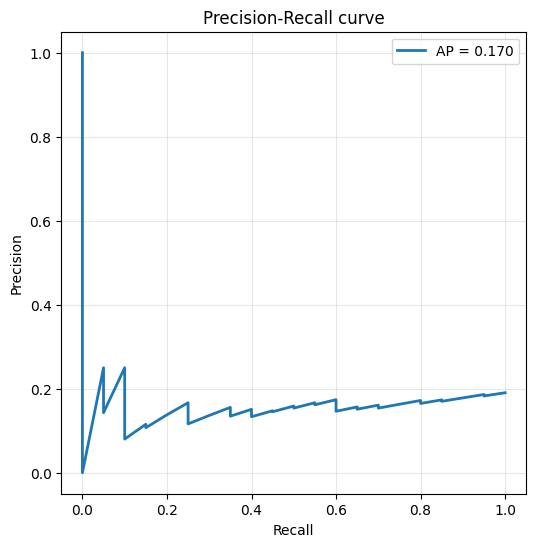

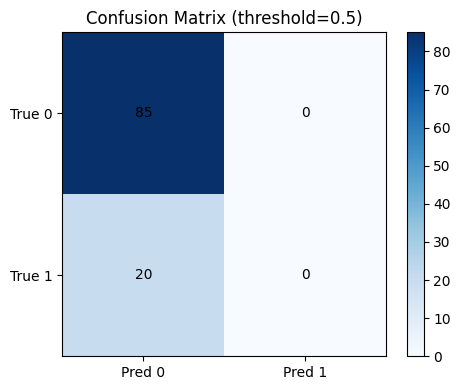

MAP:   5%|▌         | 53/1000 [00:01<00:30, 30.79it/s, logpost=-60.6657, loglik=-60.1162, logprior=-0.5495, ||grad||=0.0129, patience=49]


{'mean_auc': 0.36398148148148146, 'std_auc': 0.13521828615552248, 'min_auc': np.float64(0.1111111111111111), 'max_auc': np.float64(0.5185185185185185), 'n_folds': 5}


In [152]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_H1_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:  17%|█▋        | 4193/25000 [00:15<01:16, 273.24it/s, logpost=-50.6240, loglik=-50.6240, logprior=0.0000, ||grad||=0.0100, patience=100]


[STOP] Early stopping at iter 4192 (no improvement in 101 steps)

Best log-posterior: -50.6240


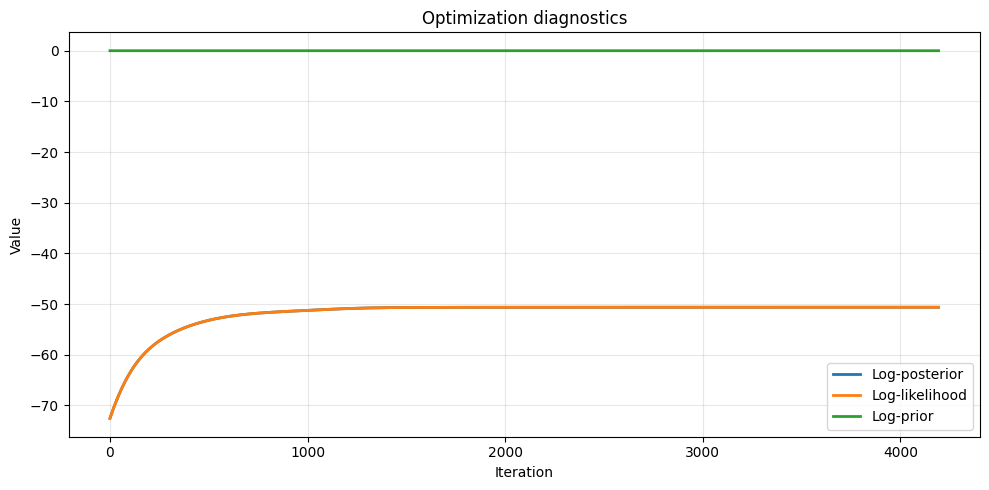

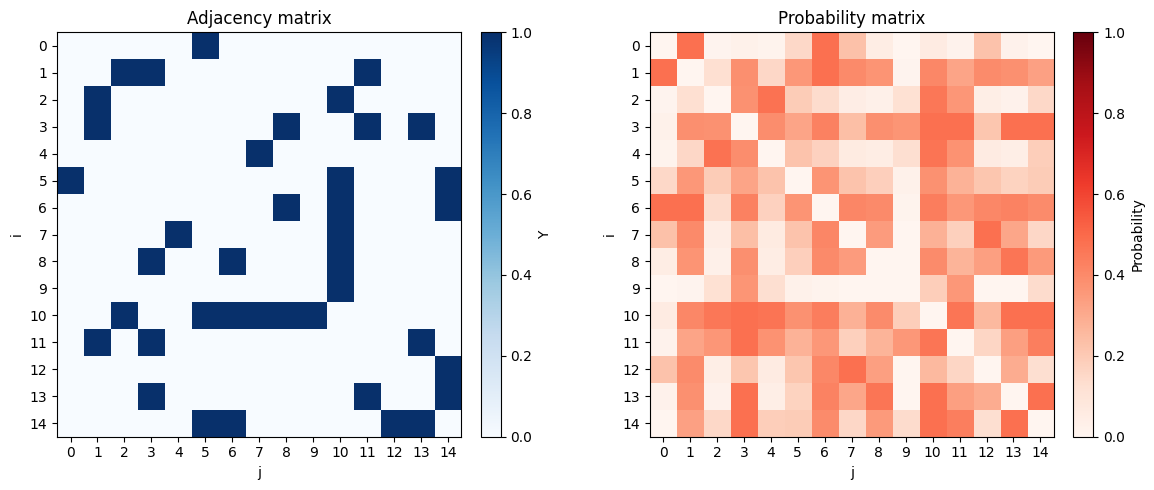

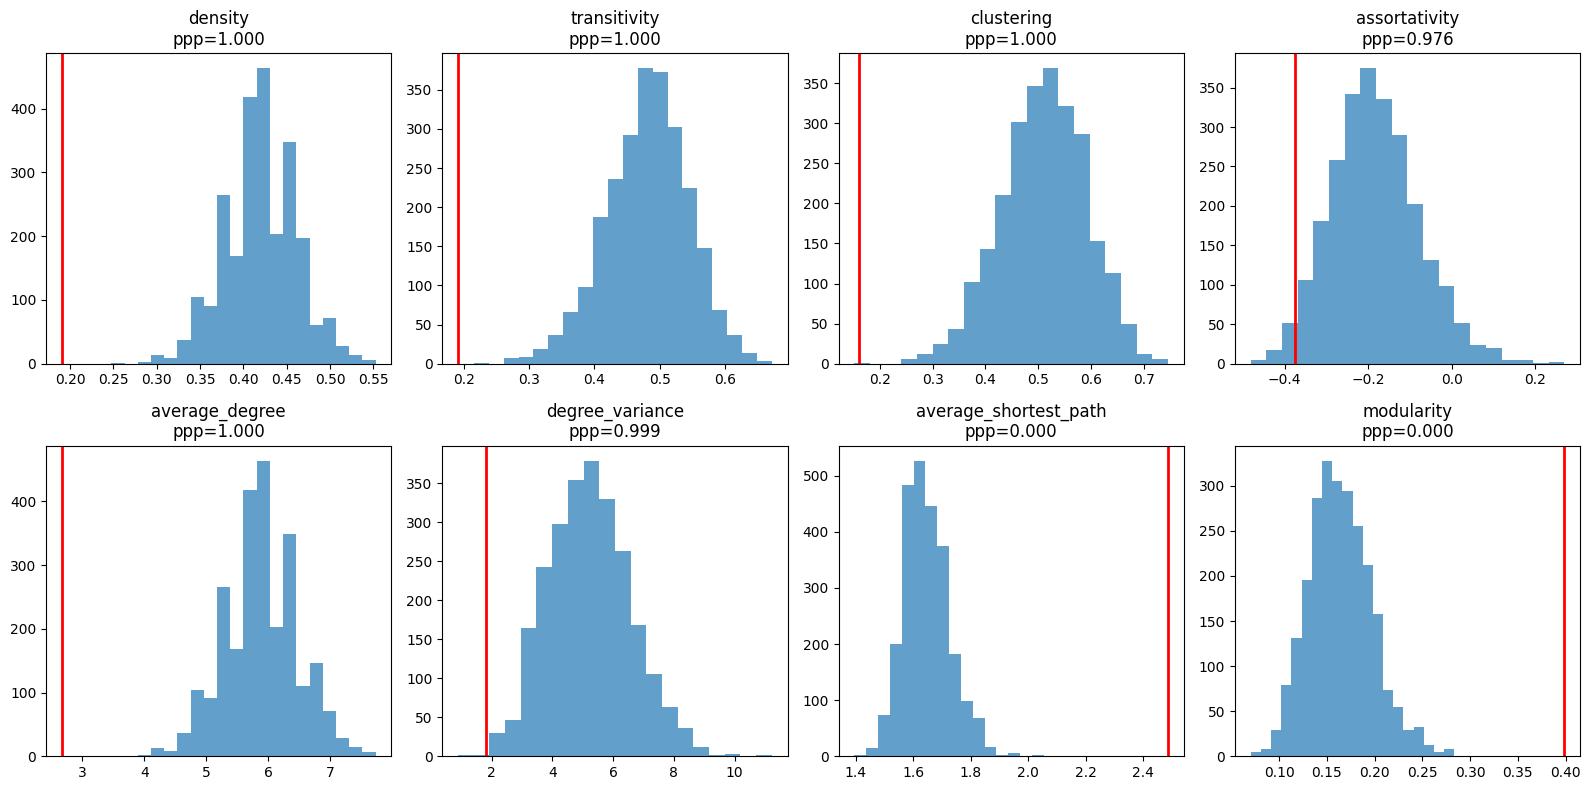

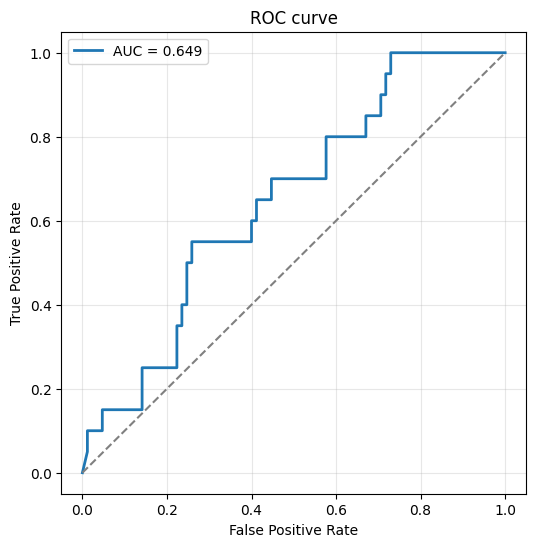

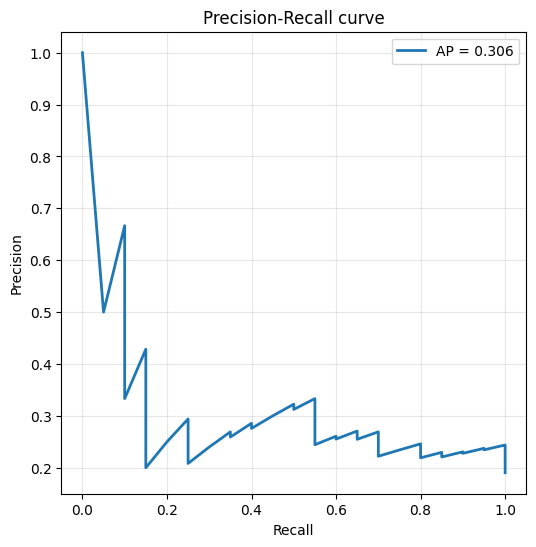

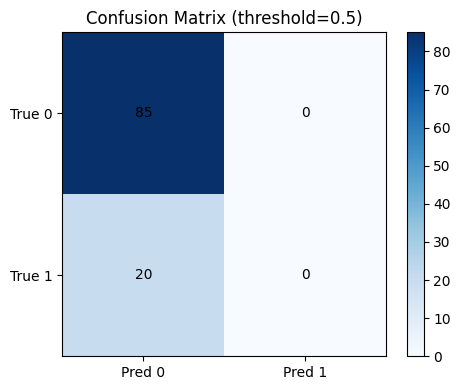

MAP: 100%|██████████| 1000/1000 [00:04<00:00, 222.75it/s, logpost=-37.8015, loglik=-37.8015, logprior=0.0000, ||grad||=0.0100, patience=0]


{'mean_auc': 0.43953703703703706, 'std_auc': 0.15337190872787387, 'min_auc': np.float64(0.23333333333333334), 'max_auc': np.float64(0.6125), 'n_folds': 5}


In [153]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_H1_p.pkl")

### Model $\mathbb{H}^2$

#### Without weights

In [ ]:
with open("Florentine_R2_p.pkl", "rb") as f:
    results_R2_p = pickle.load(f)

Z_init = np.zeros((n,3))
Z_init[:,0:2] = np.asarray(results_R2_p['latent_params']['Z'])

Multi_start (1)


MAP:   4%|▍         | 1081/25000 [00:09<03:28, 114.93it/s, logpost=-25.1149, loglik=-23.6304, logprior=-1.4845, ||grad||=0.0127, patience=100]


[STOP] Early stopping at iter 1080 (no improvement in 101 steps)

Best log-posterior: -25.1149


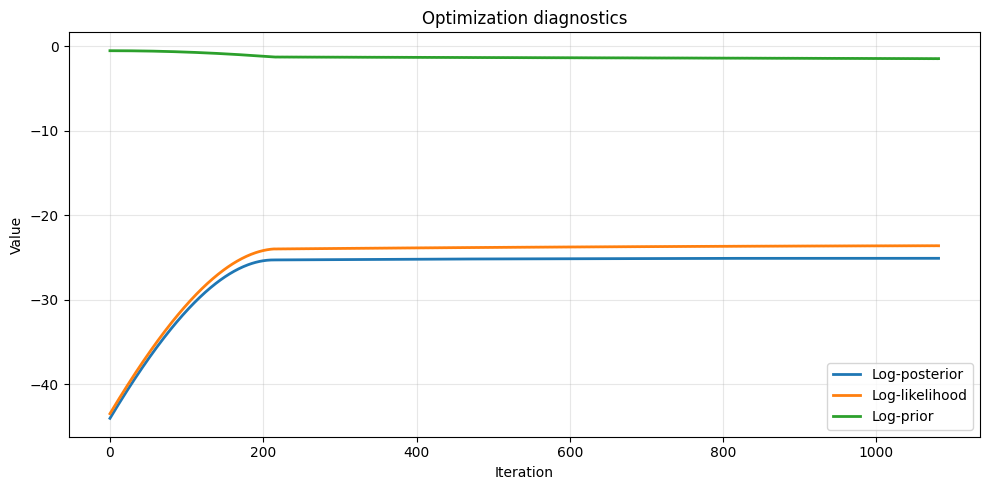

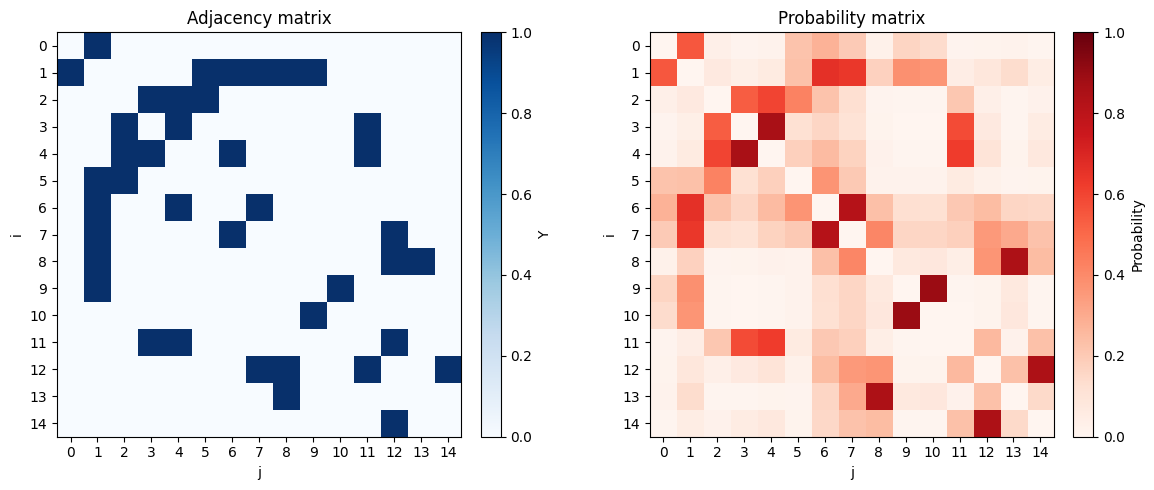

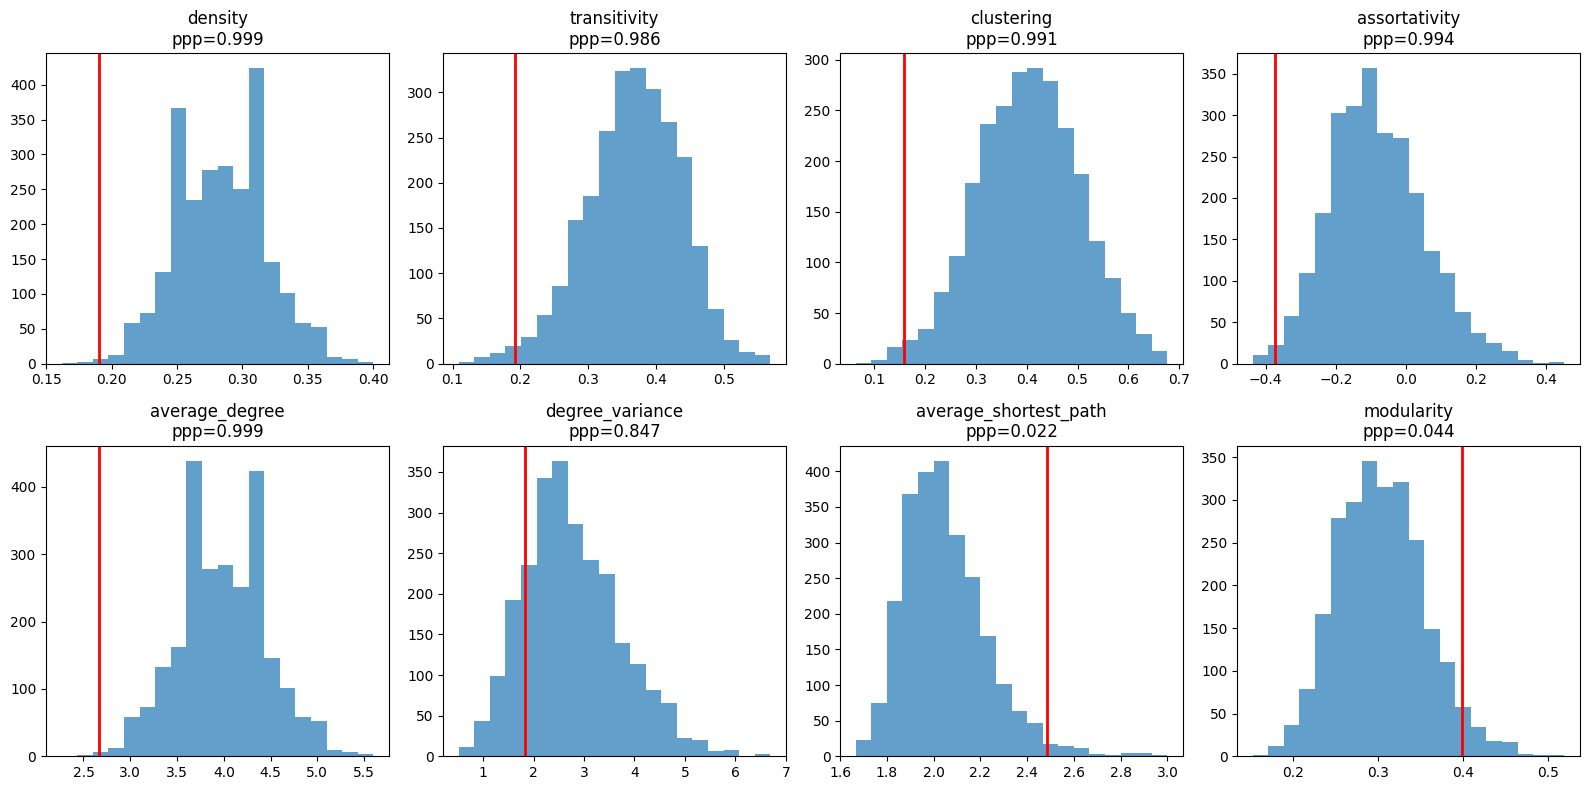

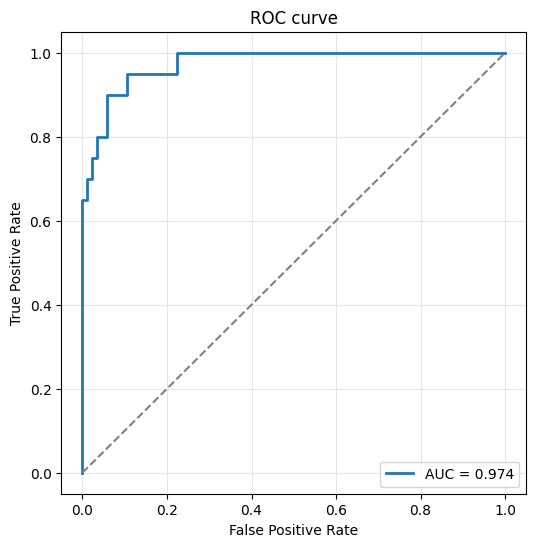

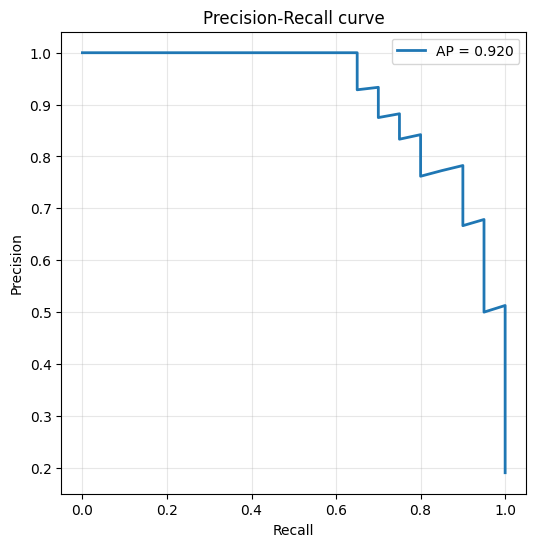

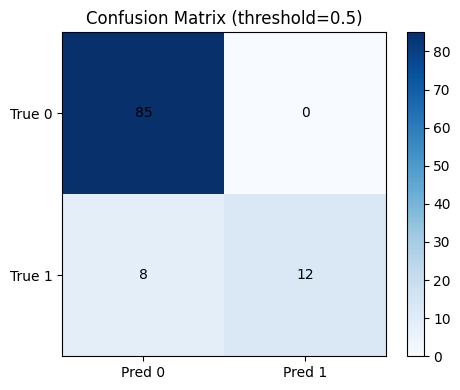

MAP:  86%|████████▌ | 861/1000 [00:07<00:01, 119.93it/s, logpost=-16.6401, loglik=-15.2161, logprior=-1.4240, ||grad||=0.0125, patience=49]


{'mean_auc': 0.9718518518518519, 'std_auc': 0.04758070178593103, 'min_auc': np.float64(0.8777777777777778), 'max_auc': np.float64(1.0), 'n_folds': 5}


In [24]:
geometry = HyperbolicGeometry(d=2, D=10.0)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_H2_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:   4%|▎         | 903/25000 [00:05<02:21, 169.83it/s, logpost=-20.0028, loglik=-20.0028, logprior=0.0000, ||grad||=0.0067, patience=100]


[STOP] Early stopping at iter 902 (no improvement in 101 steps)

Best log-posterior: -20.0028


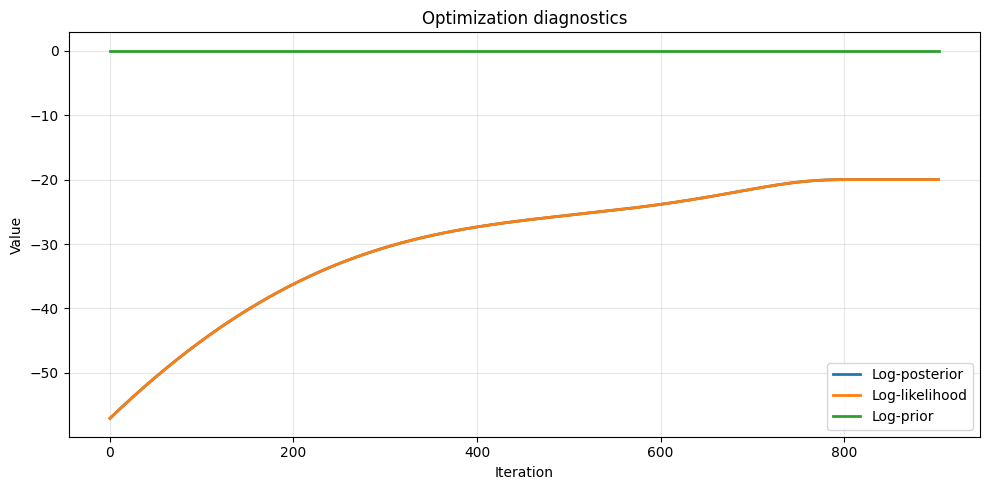

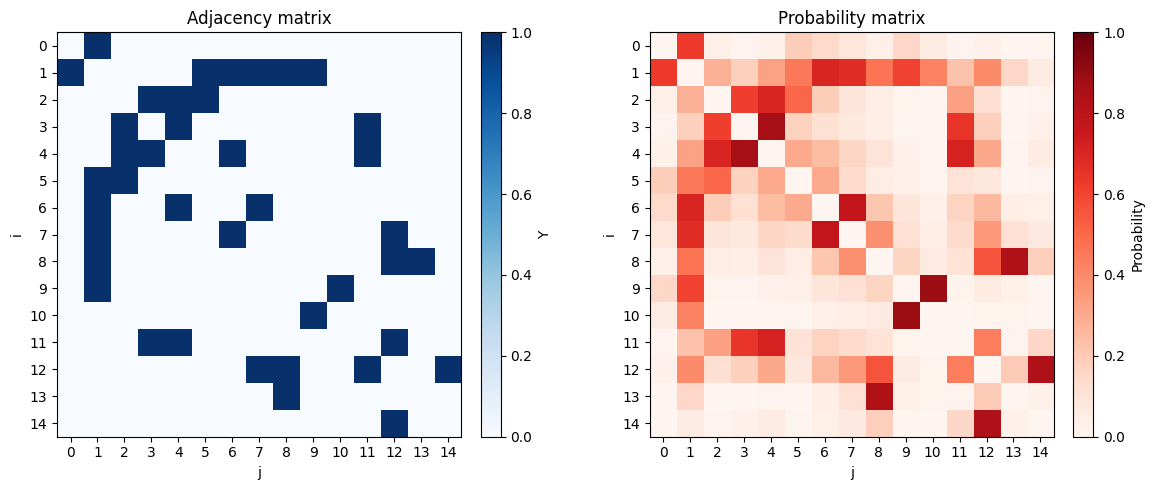

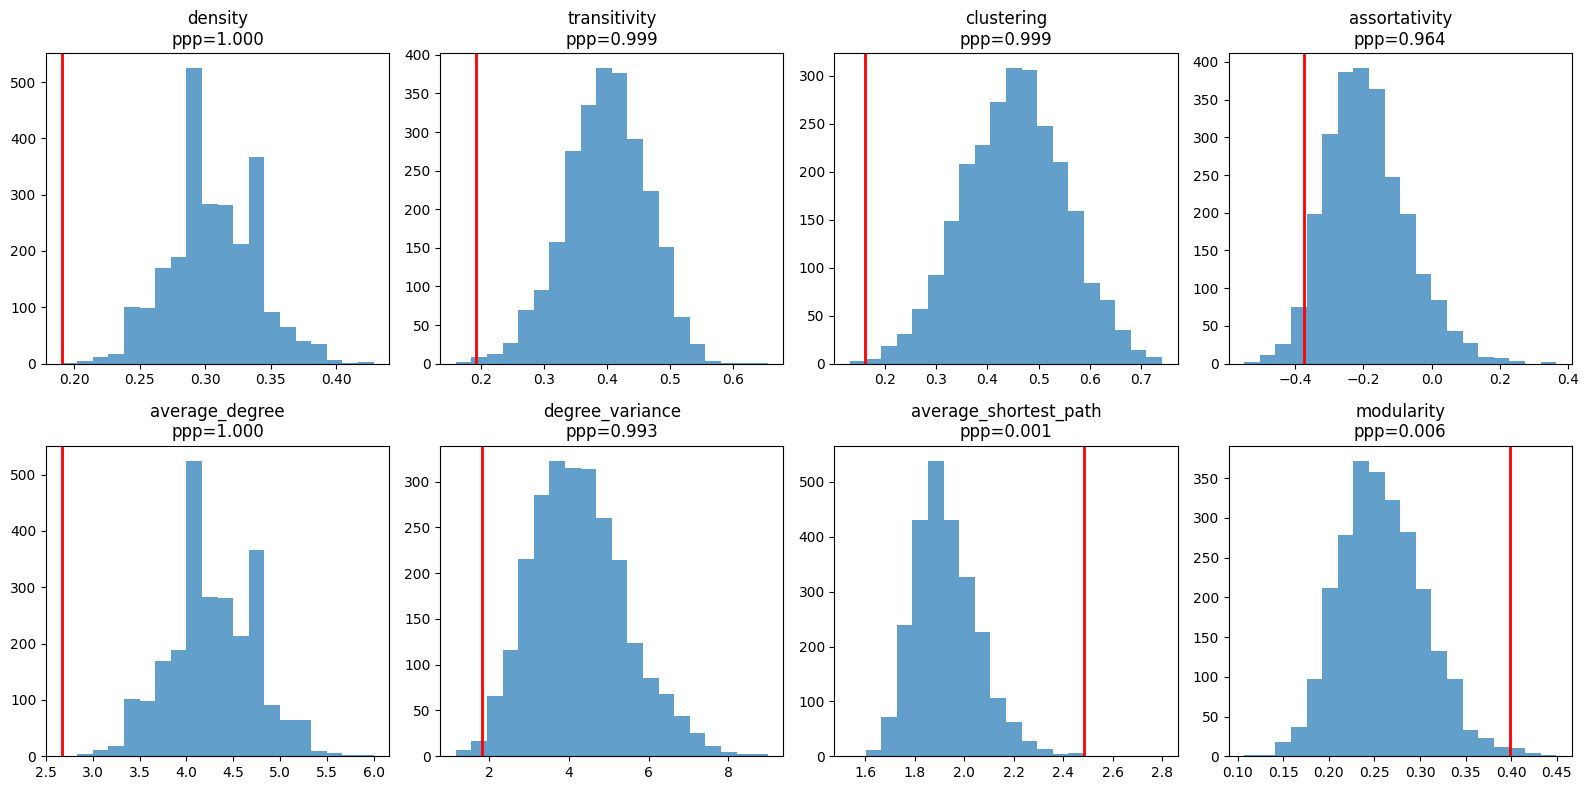

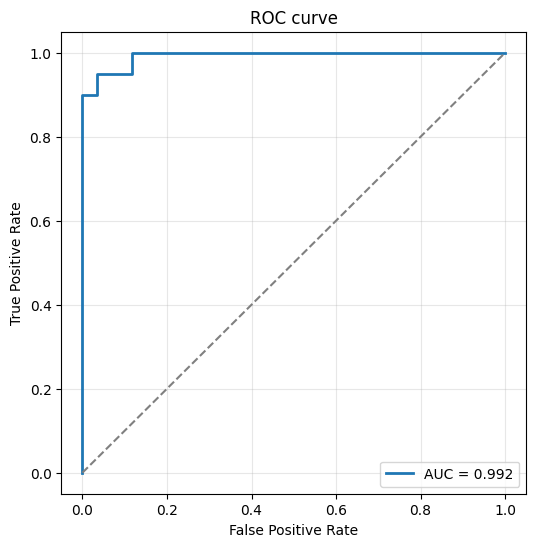

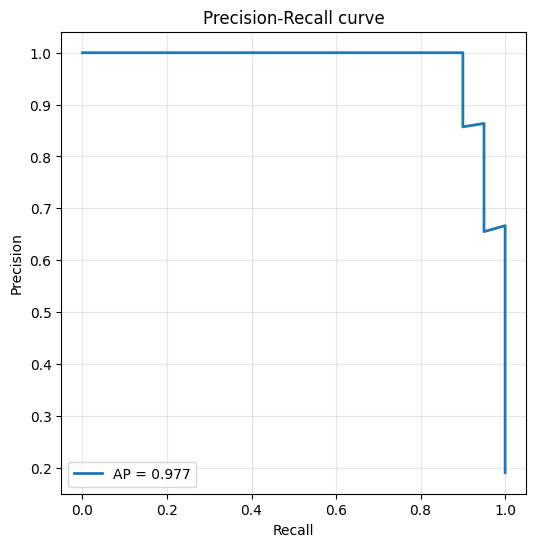

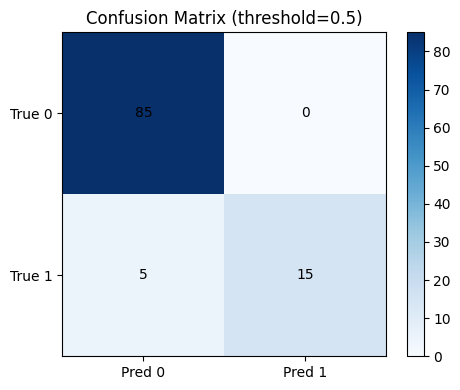

MAP:  13%|█▎        | 127/1000 [00:01<00:09, 91.98it/s, logpost=-13.1916, loglik=-13.1916, logprior=0.0000, ||grad||=0.0052, patience=49]


{'mean_auc': 0.9556917211328976, 'std_auc': 0.039099356932706754, 'min_auc': np.float64(0.8888888888888888), 'max_auc': np.float64(1.0), 'n_folds': 5}


In [25]:
geometry = HyperbolicGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=0.9*lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_H2_p.pkl")

## Results

### Visualization of latent spaces 

$\mathbb{R}^1$

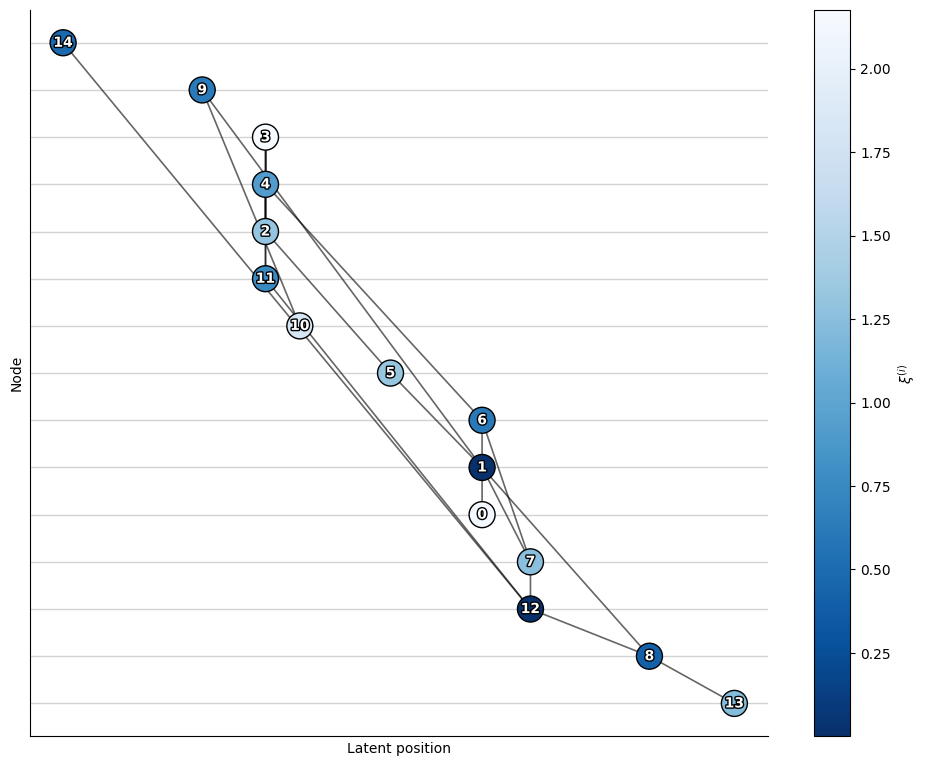

In [154]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patheffects as pe
with open("Florentine_R1_p.pkl", "rb") as f:
    results = pickle.load(f)
z = np.asarray(results["latent_params"]["Z"]).ravel()
xi = np.asarray(results["latent_params"]["xi"]).ravel()
Y = np.asarray(results["Y"])
n = len(z)
perm = np.argsort(z)
z = z[perm]
xi = xi[perm]
Y = Y[np.ix_(perm, perm)]
labels = perm
y = np.arange(n)
norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
cmap = plt.cm.Blues_r
fig, ax = plt.subplots(figsize=(10, 8))
for i in range(n):
    ax.axhline(y=i, color="lightgray", lw=1, zorder=0)
for i in range(n):
    for j in range(i + 1, n):
        if Y[i, j] > 0:
            ax.plot([z[i], z[j]], [y[i], y[j]], color="black", lw=1.2, alpha=0.6, zorder=1 )

sc = ax.scatter(z, y, c=xi, cmap=cmap, norm=norm, s=350, edgecolor="black", zorder=3)
for i in range(n):
    txt = ax.text(z[i], y[i], str(labels[i]), color="white", fontsize=10, fontweight="bold", ha="center", va="center")
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Latent position")
ax.set_ylabel("Node")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
ax.set_xticks([])
ax.set_yticks([])
plt.show()

$\mathbb{R}^2$

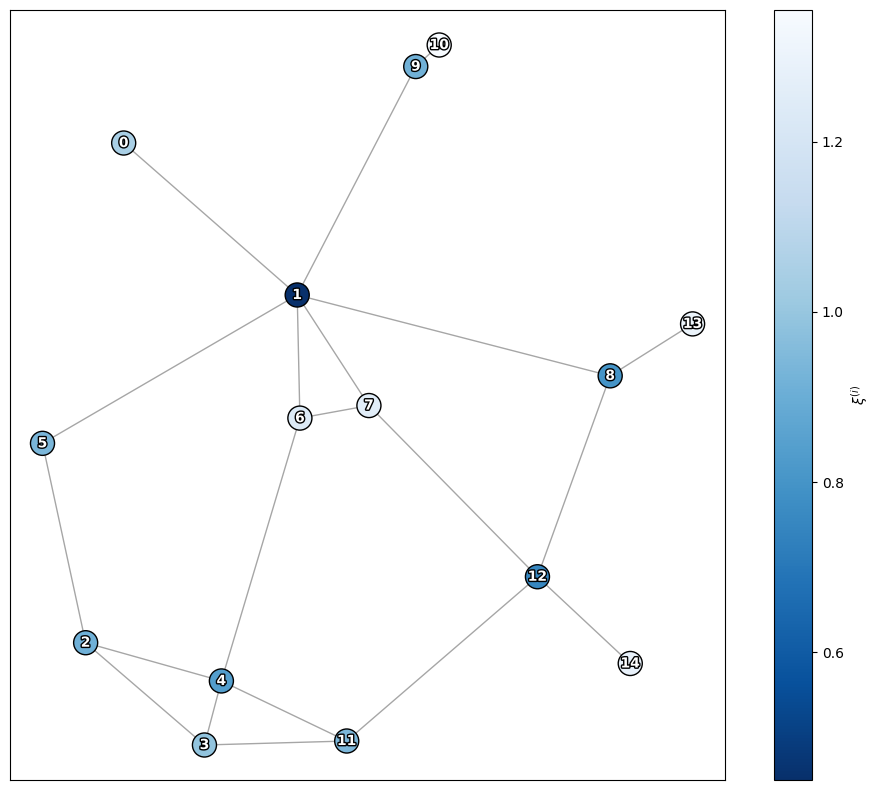

In [155]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patheffects as pe
with open("Florentine_R2_p.pkl", "rb") as f:
    results_R2_p = pickle.load(f)
Z = np.asarray(results_R2_p['latent_params']['Z'])
xi = np.asarray(results_R2_p['latent_params']['xi']).ravel()
Y = np.asarray(results_R2_p['Y'])
n = len(xi)
x = Z[:, 0]
y = Z[:, 1]
fig, ax = plt.subplots(figsize=(10, 8))
for i in range(n):
    for j in range(i + 1, n):
        if Y[i, j] > 0:
            ax.plot([x[i], x[j]], [y[i], y[j]], color="black", alpha=0.35, lw=1.0, zorder=1)
norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
sc = ax.scatter(x, y, c=xi, cmap="Blues_r", norm=norm, s=300, edgecolor="black", zorder=3)
for i in range(n):
    txt = ax.text(x[i], y[i], str(i), color="white", fontsize=10, fontweight="bold", ha="center", va="center")
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_aspect("equal")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

$\mathbb{R}^3$

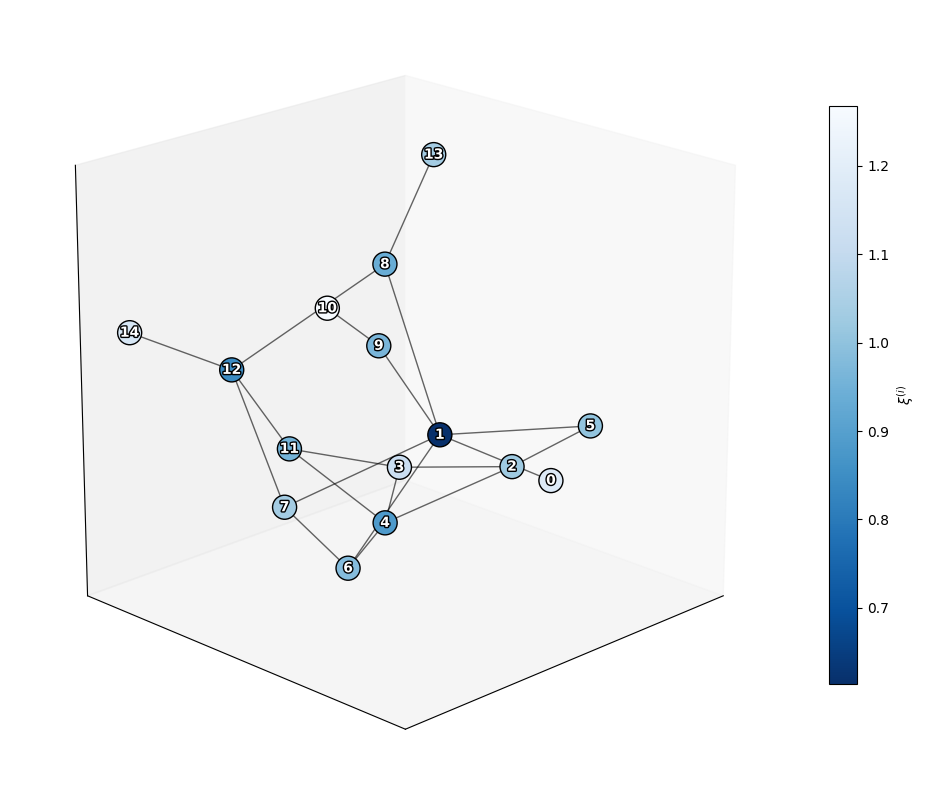

In [156]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patheffects as pe
with open("Florentine_R3_p.pkl", "rb") as f:
    results_R3_p = pickle.load(f)
Z = np.asarray(results_R3_p["latent_params"]["Z"])
xi = np.asarray(results_R3_p["latent_params"]["xi"]).ravel()
Y = np.asarray(results_R3_p["Y"])
n = len(xi)
x = Z[:, 0]
y = Z[:, 1]
z = Z[:, 2]
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
for i in range(n):
    for j in range(i + 1, n):
        if Y[i, j] > 0:
            ax.plot([x[i], x[j]], [y[i], y[j]], [z[i], z[j]], color="black", alpha=0.6, lw=1.0, zorder=1)
norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
sc = ax.scatter(x, y, z, c=xi, cmap="Blues_r", norm=norm, s=300, edgecolors="black", depthshade=True, zorder=3, alpha=1.0)
for i in range(n):
    txt = ax.text(x[i], y[i], z[i], str(i), color="white", fontsize=10, fontweight="bold", ha="center", va="center")
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])
cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.grid(False)
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

$\mathbb{S}^1$

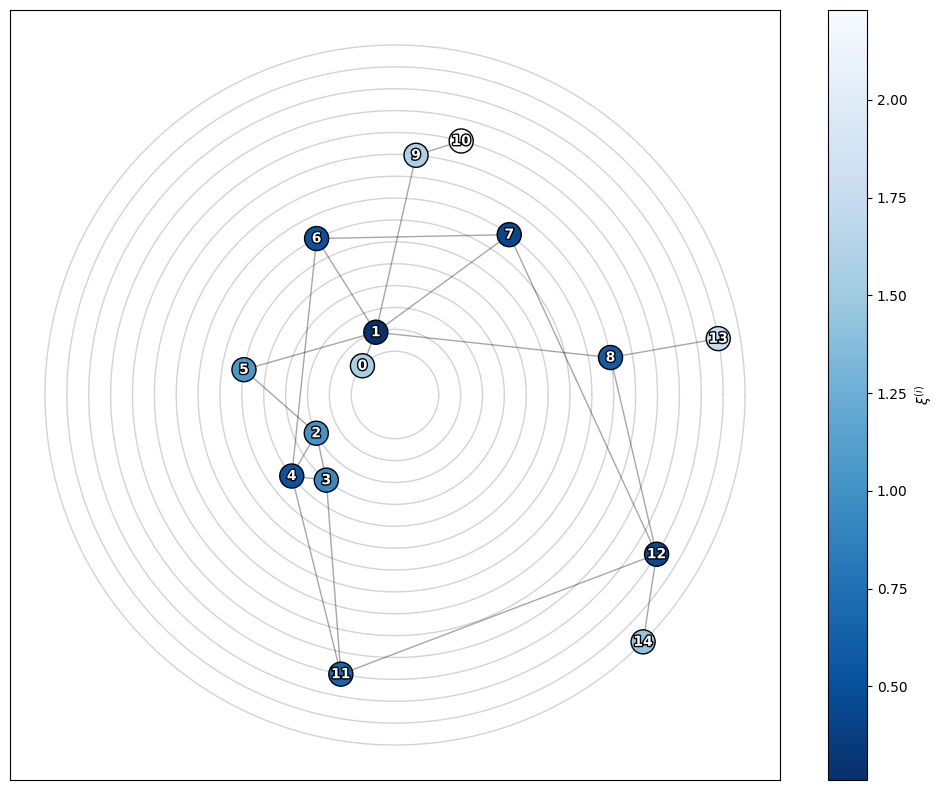

In [157]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patheffects as pe
with open("Florentine_S1_p.pkl", "rb") as f:
    results_S1_p = pickle.load(f)
Z  = np.asarray(results_S1_p["latent_params"]["Z"])
xi = np.asarray(results_S1_p["latent_params"]["xi"]).ravel()
Y  = np.asarray(results_S1_p["Y"])
n = len(xi)
theta = np.arctan2(Z[:,1], Z[:,0])
r0 = 1.0
dr = 0.5
radii = r0 + dr*np.arange(n)
x = radii*np.cos(theta)
y = radii*np.sin(theta)
fig, ax = plt.subplots(figsize=(10,8))
tt = np.linspace(0, 2*np.pi, 500)
for r in radii:
    ax.plot(r*np.cos(tt), r*np.sin(tt), color="lightgray", lw=1, zorder=0)
for i in range(n):
    for j in range(i+1,n):
        if Y[i,j] > 0:
            ax.plot([x[i],x[j]], [y[i],y[j]], color="black", alpha=0.35, lw=1.0, zorder=1)
norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
sc = ax.scatter(x, y, c=xi, cmap="Blues_r", norm=norm, s=300, edgecolor="black", zorder=3)
for i in range(n):
    txt = ax.text(x[i], y[i], str(i), color="white", fontsize=10, fontweight="bold", ha="center", va="center", zorder=4)
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

$\mathbb{S}^2$

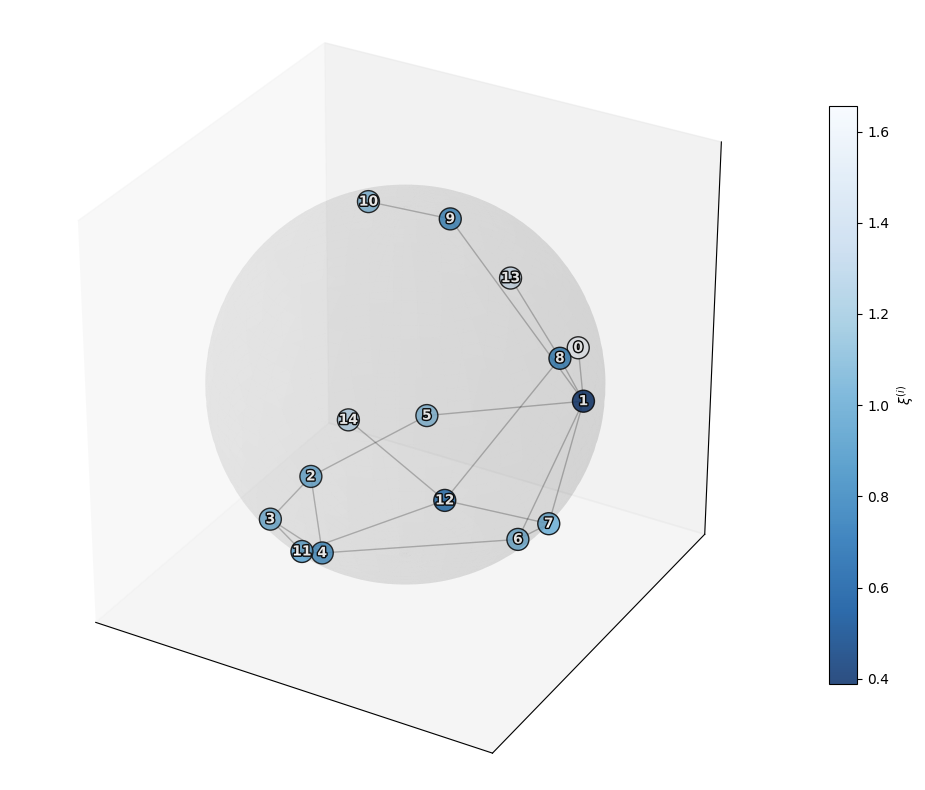

In [158]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patheffects as pe

with open("Florentine_S2_p.pkl", "rb") as f:
    results_S2_p = pickle.load(f)
Z = np.asarray(results_S2_p["latent_params"]["Z"])
xi = np.asarray(results_S2_p["latent_params"]["xi"]).ravel()
Y = np.asarray(results_S2_p["Y"])
n = len(xi)
x = Z[:, 0]
y = Z[:, 1]
z = Z[:, 2]
R = (x[0]**2 + y[0]**2  + z[0]**2)**0.5
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, np.pi, 100)
xs = R*np.outer(np.cos(u), np.sin(v))
ys = R*np.outer(np.sin(u), np.sin(v))
zs = R*np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(xs, ys, zs, alpha=0.08, color="gray", linewidth=0, zorder=0)
for i in range(n):
    for j in range(i + 1, n):
        if Y[i, j] > 0:
            ax.plot([x[i], x[j]], [y[i], y[j]], [z[i], z[j]], color="black", alpha=0.25, lw=1.0, zorder=1)
norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
sc = ax.scatter(x, y, z, c=xi, cmap="Blues_r", norm=norm, s=250, edgecolors="black", depthshade=True, zorder=3, alpha=0.85)
for i in range(n):
    txt = ax.text(x[i], y[i], z[i], str(i), color="white", fontsize=10, fontweight="bold", ha="center", va="center")
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])
cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_box_aspect([1,1,1])
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
ax.grid(False)
plt.tight_layout()
plt.show()

$\mathbb{H}^1$

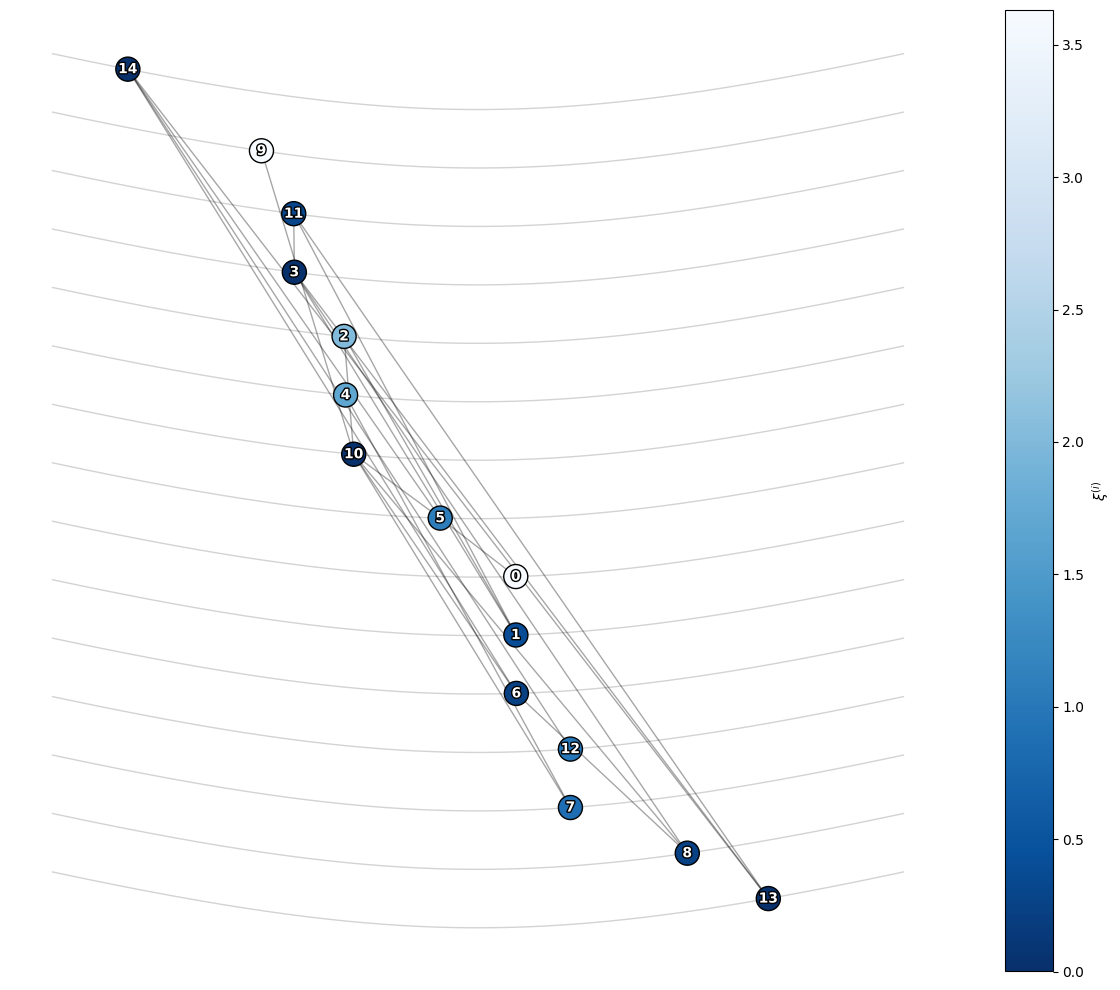

In [159]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patheffects as pe
with open("Florentine_H1_p.pkl", "rb") as f:
    results_H1_p = pickle.load(f)
diam = 10.0
R = diam / np.pi
Z = np.asarray(results_H1_p["latent_params"]["Z"])
xi = np.asarray(results_H1_p["latent_params"]["xi"]).ravel()
Y = np.asarray(results_H1_p["Y"])
n = len(xi)
x0 = Z[:, 0]
x1 = Z[:, 1]
t_nodes = np.arcsinh(x0 / R)
perm = np.argsort(t_nodes)
t_nodes = t_nodes[perm]
xi = xi[perm]
Y = Y[np.ix_(perm, perm)]
labels = perm
lim_range_t = max(np.max(np.abs(t_nodes))*1.15, np.pi/3)
t = np.linspace(-lim_range_t, lim_range_t, 1000)
base_x = R*np.sinh(t)
base_y = R*np.cosh(t)
spacing = 2.0
node_x = np.zeros(n)
node_y = np.zeros(n)
fig, ax = plt.subplots(figsize=(12,10))
for i in range(n):
    offset = -i*spacing
    ax.plot(base_x, base_y + offset, color="lightgray", lw=1.0, zorder=0)
    node_x[i] = R*np.sinh(t_nodes[i])
    node_y[i] = R*np.cosh(t_nodes[i]) + offset
for i in range(n):
    for j in range(i+1, n):
        if Y[i,j] > 0:
            ax.plot([node_x[i], node_x[j]], [node_y[i], node_y[j]], color="black", alpha=0.35, lw=1.0, zorder=1)
norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
sc = ax.scatter(node_x, node_y, c=xi, cmap="Blues_r", norm=norm, s=300, edgecolor="black", zorder=3)
for i in range(n):
    txt = ax.text(node_x[i], node_y[i], str(labels[i]), color="white", fontsize=10, fontweight="bold",ha="center",va="center",zorder=4)
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

$\mathbb{H}^2$

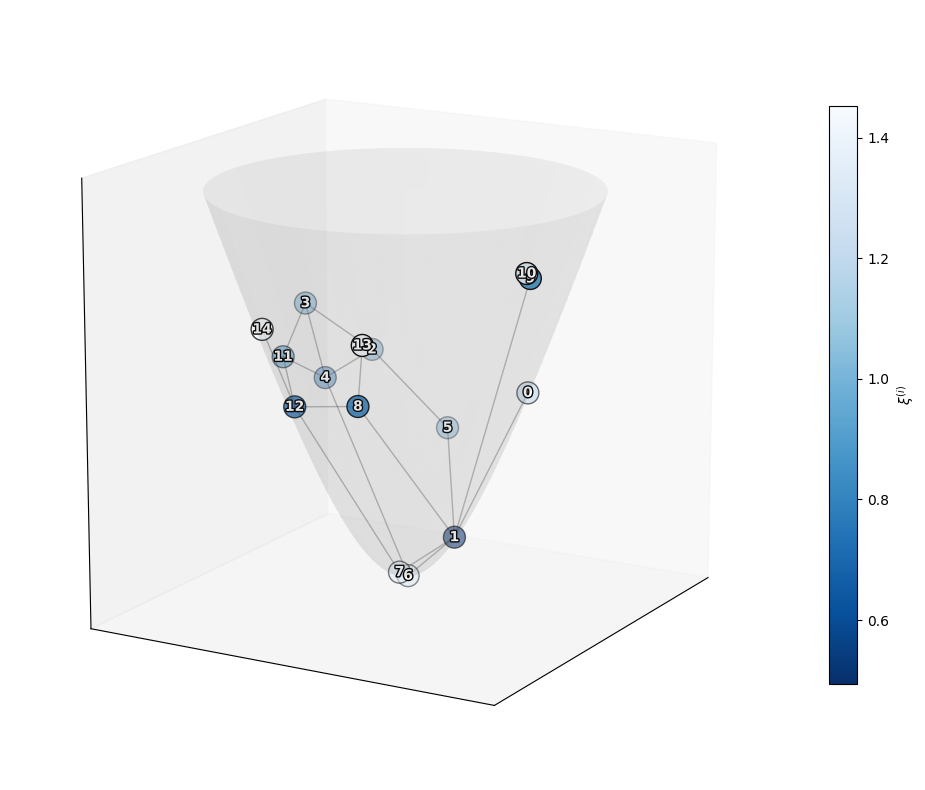

In [160]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patheffects as pe
with open("Florentine_H2_p.pkl", "rb") as f:
    results_H2_p = pickle.load(f)
Z = np.asarray(results_H2_p["latent_params"]["Z"])
xi = np.asarray(results_H2_p["latent_params"]["xi"]).ravel()
Y = np.asarray(results_H2_p["Y"])
n = len(xi)
x0 = Z[:, 0]
x1 = Z[:, 1]
x2 = Z[:, 2]
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
rmax = np.max(np.sqrt(x1**2 + x2**2)) * 0.75
r = np.linspace(0, rmax, 100)
theta = np.linspace(0, 2*np.pi, 150)
R, Theta = np.meshgrid(r, theta)
X1 = R * np.cos(Theta)
X2 = R * np.sin(Theta)
X0 = np.sqrt((diam/np.pi)**2 + X1**2 + X2**2)
ax.plot_surface(X1, X2, X0, alpha=0.08, color="gray", linewidth=0, antialiased=True)
for i in range(n):
    for j in range(i + 1, n):
        if Y[i, j] > 0:
            ax.plot([x0[i], x0[j]], [x1[i], x1[j]],  [x2[i], x2[j]], color="black", alpha=0.25, lw=1.0)
norm = Normalize(vmin=np.min(xi), vmax=np.max(xi))
sc = ax.scatter(x0, x1, x2, c=xi, cmap="Blues_r", norm=norm, s=250, edgecolors="black", depthshade=True)
for i in range(n):
    txt = ax.text(x0[i], x1[i], x2[i], str(i), color="white", fontsize=10, fontweight="bold", ha="center", va="center")
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])
cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label(r"$\xi^{(i)}$")
ax.set_box_aspect([1,1,1])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.grid(False)
ax.view_init(elev=15, azim=30)
plt.tight_layout()
plt.show()

### Visualization of probability matrices

### Model statistics

### Internal validation

### External validation